<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Baldness Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 10**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:**  https://github.com/mariamiguel720/Big-Data-Analytics-Project-25-26

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
- [5. Data Exploration](#5)
- [6. Undersampling](#6)
- [7. Data Quality Checks](#7)
- [8. Data Split](#8)
- [9. Outlier Analysis](#9)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

This notebook is developed in the context of a consulting engagement for a client operating 
in the computer vision space. The client requires a scalable solution to automatically 
classify facial images as **Bald** or **Not Bald**, a binary image classification problem.

Given the large volume of image data involved (+200k images), **Apache Spark (PySpark)** 
is used as the core processing framework, ensuring the pipeline is designed to scale 
horizontally across distributed environments.


# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
# ! pip install pyspark huggingface_hub python-dotenv
# ! pip install "pandas>=2.2.0" --upgrade
# ! pip install pyarrow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 MB 109.8 MB/s  0:00:0300:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 46.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 159.5 MB/s  0:00:00
  Created wheel for pyspark: filename=pyspark-4.1.2-py2.py3-none-any.whl size=456079515 sha256=47728e93c285c954323b473ad7c137ed643dee2f1d1cb0055287a6b01e628c6a
  Stored in directory: /home/zeus/.cache/pip/wheels/e6/9c/35/b08622081a09dc48b9467b570ae170519430915aa3c8d27cf9
Successfully built pyspark
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [huggingface_hub] [huggingface_hub]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.7 MB/s  0:00:00
  Attempting uninstall: pandas
    Found existing

In [ ]:
# IMPORT LIBRARIES
import random
import os
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, FloatType, ArrayType, DoubleType, IntegerType, BinaryType

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Summarizer
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

from scipy.ndimage import uniform_filter, sobel as scipy_sobel

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import pyarrow.parquet as pq
from pyspark.ml.torch.distributor import TorchDistributor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

import sys
sys.path.append("/teamspace/studios/this_studio/notebooks/Baldness")

from baldness_functions import *

In [25]:
# # Install Java 17 (Required for Spark)
# !sudo apt-get update
# !sudo apt-get install -y openjdk-17-jdk-headless
# !java -version

In [2]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
!java -version

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-24.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-24.04.2-Ubuntu, mixed mode, sharing)


In [3]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BaldClassification")
    .config("spark.driver.memory", "12g")
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/03 19:35:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


In [ ]:
# DEFINE DATA PATHS
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "../../data/Data_Bald_People/Raw"))
SPLITS    = ["Train", "Validation", "Test"]
LABELS    = ["Bald", "NotBald"]

In [5]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

Images are loaded using Spark's native `binaryFile` format, which reads each image as a 
row containing its path, raw binary content, and file size. This approach is big-data-safe 
as it leverages Spark's distributed file reading capabilities and does not rely on local I/O.

Each subset (split × label combination) is loaded separately and tagged with its 
corresponding label and split metadata before being unioned into a single DataFrame.

In [8]:
# Collect individual DataFrames for each split/label combination
dfs = []

for split in SPLITS:
    for label in LABELS:
        folder = os.path.join(BASE_PATH, split, label)

        df_part = (
            spark.read.format("binaryFile")
            .option("pathGlobFilter", "*.jpg")   # filter to JPEG images only
            .option("recursiveFileLookup", "false")  # images are directly in the folder, no subdirectories
            .load(folder)
            .select(
                F.col("path"),
                F.col("content"),                          # raw image bytes
                F.col("length").alias("file_size_bytes"),  # file size in bytes
            )
            .withColumn("label",          F.lit(label))
            .withColumn("label_index",    F.lit(1 if label == "Bald" else 0).cast("integer"))  # Bald=1, NotBald=0
            .withColumn("original_split", F.lit(split))
        )

        dfs.append(df_part)
        print(f"  Loaded {split}/{label}")

  Loaded Train/Bald


26/06/02 21:41:42 WARN SharedInMemoryCache: Evicting cached table partition metadata from memory due to size constraints (spark.sql.hive.filesourcePartitionFileCacheSize = 262144000 bytes). This may impact query planning performance.


  Loaded Train/NotBald
  Loaded Validation/Bald
  Loaded Validation/NotBald
  Loaded Test/Bald
  Loaded Test/NotBald


In [ ]:
# Union all partial DataFrames into a single DataFrame
df_all = dfs[0]
for df in dfs[1:]:
    df_all = df_all.union(df)

# Cache the unified DataFrame to avoid re-reading files in subsequent operations
df_all.cache()
print(f"\nTotal images loaded: {df_all.count():,}")

In [ ]:
# Repartition to consolidate the large number of partitions inherited from binaryFile reads.
# binaryFile creates one partition per file group, resulting in 12k+ partitions for this dataset.
# With only 13k images after undersampling, this means ~1 image per partition — extremely inefficient.
# Repartitioning to 8 partitions reduces task overhead significantly for all subsequent operations.
# NOTE: repartition() triggers a full shuffle — this one-time cost is justified by the
# performance gains in all downstream operations (feature extraction, K-Means, aggregations).
df_all = df_all.repartition(8).cache()

# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 Class Distribution**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

The metadata DataFrame (excluding raw image bytes) is registered as a Spark SQL temporary 
view to enable SQL-style querying. This demonstrates Spark's ability to mix DataFrame 
and SQL APIs seamlessly.

The distribution of images across splits and classes is computed to quantify the severity 
of the class imbalance identified in the Project Overview.

In [21]:
# Drop the raw image content column to create a lightweight metadata-only DataFrame
# This avoids carrying binary data through aggregations, which is critical at scale
df_meta = df_all.drop("content")
df_meta.createOrReplaceTempView("image_metadata")

# Query the distribution of images per split and label using SparkSQL
# NOTE: ORDER BY in SQL is not guaranteed to be stable across distributed partitions.
# This is acceptable here as the query is used only for display purposes.
df_class_dist = spark.sql("""
    SELECT original_split, label, COUNT(*) AS n_images
    FROM image_metadata
    GROUP BY original_split, label
    ORDER BY original_split, label
""")
df_class_dist.show()

# Aggregate total counts per class across all splits
# NOTE: toPandas() collects all data to the driver node and is not big-data-safe.
# It is used here only because the aggregated result is a very small DataFrame (2 rows).
class_counts = (
    df_class_dist.groupBy("label")
    .agg(F.sum("n_images").alias("n"))
    .toPandas()
)

n_bald    = int(class_counts.loc[class_counts.label == "Bald",    "n"].values[0])
n_notbald = int(class_counts.loc[class_counts.label == "NotBald", "n"].values[0])

print(f"Bald    : {n_bald:,}")
print(f"NotBald : {n_notbald:,}")
print(f"Imbalance ratio: {round(max(n_bald, n_notbald) / min(n_bald, n_notbald), 2)}x")

# Compute the proportion of images belonging to the Train split
# NOTE: collect() is used here to retrieve a single aggregated scalar value.
# This is acceptable as the result is a single row, not a large collection.
train_total = df_class_dist.filter(F.col("original_split") == "Train").agg(F.sum("n_images")).collect()[0][0]
total = df_all.count()
print(f"Train split share: {round(train_total / total * 100, 1)}%")

+--------------+-------+--------+
|original_split|  label|n_images|
+--------------+-------+--------+
|          Test|   Bald|     421|
|          Test|NotBald|   19579|
|         Train|   Bald|    3656|
|         Train|NotBald|  156344|
|    Validation|   Bald|     470|
|    Validation|NotBald|   22129|
+--------------+-------+--------+

Bald    : 4,547
NotBald : 198,052
Imbalance ratio: 43.56x
Train split share: 79.0%


**Key findings:**
- The dataset is heavily imbalanced: NotBald images outnumber Bald by a ratio of **43.56x**
- This imbalance is consistent across all three splits, confirming it is a structural 
  property of the dataset and not an artifact of the split process
- The Train split dominates the dataset, containing ~78% of all images

## <font color='#2f94d7' size=6>**4.2 Visual Sample Inspection**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

A random sample of images from each class is displayed to allow qualitative assessment 
of image quality, label correctness, and visual diversity within each class.

/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_84196/999549204.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


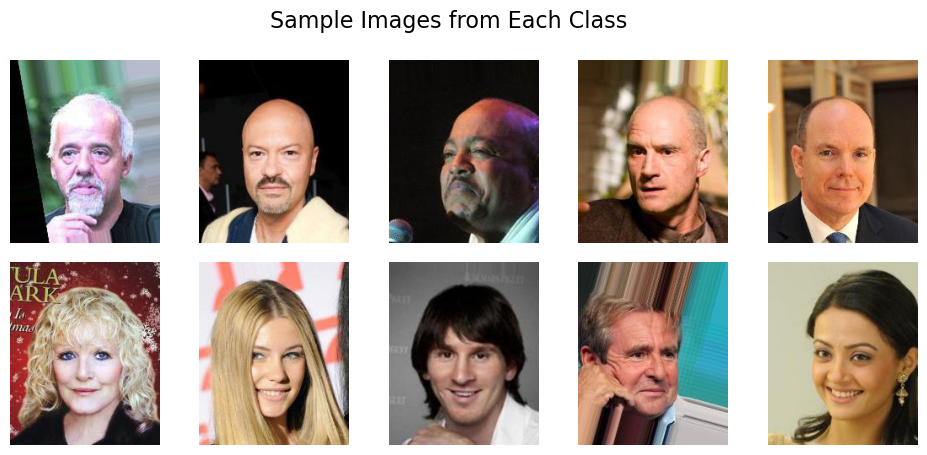

In [ ]:
# Visualise a random sample of images from each class to inspect data quality
# NOTE: orderBy(F.rand()) is not fully deterministic in distributed environments,
# as the result may vary depending on the number of partitions at runtime.
# A seed is provided for best-effort reproducibility in single-node execution.
# NOTE: toPandas() and iterrows() are used here only because the sample is very small
# (n_samples=5 per class). This would not be appropriate for large collections of images.
n_samples = 5
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, n_samples, wspace=0.1, hspace=0.1)

for i, label in enumerate(LABELS):
    df_sample = (
        df_all.filter(F.col("label") == label)
        .orderBy(F.rand(seed=SEED))
        .limit(n_samples)
        .toPandas()
    )

    for j, (_, row) in enumerate(df_sample.iterrows()):
        img_bytes = row["content"]
        img = Image.open(io.BytesIO(img_bytes))
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(label, fontsize=12, rotation=0, labelpad=40)

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

> **Observation:** Visual inspection of the sample images reveals at least one potential 
> mislabelling in the Bald class. This will be revisited during the Outlier Analysis 
> section, where numeric features extracted from the images will be used to identify 
> and flag anomalous samples.

# <font color='#2f94d7' size=6>**5. Undersampling**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

To address the severe class imbalance (43.56x), the NotBald class is undersampled to 
achieve a **2:1 ratio** (NotBald:Bald). This is done using Spark's native `.sample()` 
method, which performs distributed approximate sampling, making it big-data-safe.

The Bald class is kept in full, as it is the minority class and every sample is valuable 
for training.

In [23]:
# n_bald and n_notbald are reused from Section 4 — no need to recompute

# Bald is the minority class; set the NotBald target to 2x the number of Bald samples (2:1 ratio)
n_notbald_target = n_bald * 2

# Compute the sampling fraction needed to reach the target count
# NOTE: Spark's sample() uses approximate sampling, so the actual result may differ
# slightly from the target. This is acceptable for the purpose of balancing the dataset.
fraction = n_notbald_target / n_notbald

print(f"Bald    (minority class)  : {n_bald:,}")
print(f"NotBald (majority class)  : {n_notbald:,}")
print(f"NotBald target (2:1)      : {n_notbald_target:,}")
print(f"Sampling fraction         : {fraction:.4f}")

# Undersample the NotBald class to the target fraction
df_notbald_sampled = (
    df_all
    .filter(F.col("label") == "NotBald")
    .sample(fraction=fraction, seed=42)
)

# Combine the full Bald class with the undersampled NotBald class
df_bald     = df_all.filter(F.col("label") == "Bald")
df_balanced = df_bald.union(df_notbald_sampled)

# Verify the resulting class distribution
# NOTE: orderBy is not guaranteed to be stable across distributed partitions;
# used here for display purposes only
df_balanced.groupBy("label").count().orderBy("label").show()
print(f"Total after undersampling: {df_balanced.count():,}")

# Cache the balanced DataFrame and release the original to free memory
# Caching is critical to avoid recomputing the sampling in subsequent operations
df_balanced.cache()
df_all.unpersist()

Bald    (minority class)  : 4,547
NotBald (majority class)  : 198,052
NotBald target (2:1)      : 9,094
Sampling fraction         : 0.0459
+-------+-----+
|  label|count|
+-------+-----+
|   Bald| 4547|
|NotBald| 9088|
+-------+-----+

Total after undersampling: 13,635


DataFrame[path: string, content: binary, file_size_bytes: bigint, label: string, label_index: int, original_split: string]

**Key findings:**
- After undersampling, the dataset is reduced from 202,599 to **13,673 images**
- The final ratio is approximately 2:1 (NotBald:Bald), as intended
- Note that Spark's `.sample()` is approximate, the actual NotBald count (9,126) 
  differs slightly from the target (9,094), which is expected behaviour

# <font color='#2f94d7' size=6>**7. Data Quality Checks**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

Two basic quality filters are applied to the balanced dataset:
- **Null content filter**: removes any records where the image binary content is missing 
  or could not be read by Spark
- **Minimum file size filter**: removes files smaller than 1,000 bytes, which are likely 
  corrupt, truncated, or placeholder images

> **Note:** A formal Spark Pipeline is not used here, as the quality checks consist of 
> simple DataFrame filters rather than feature transformations. Model-specific transforms 
> (e.g. resize, normalisation) are applied at the DataLoader level in the modelling stage.

In [24]:
# Record total image count before applying quality filters
total_before = df_balanced.count()
print(f"Total before quality filter : {total_before:,}")

# Apply quality filters:
# 1. Remove records where image content is null (unreadable or missing files)
# 2. Remove files smaller than 1000 bytes (likely corrupt or placeholder images)
df_quality = (
    df_balanced
    .filter(F.col("content").isNotNull())
    .filter(F.length(F.col("content")) >= 1000)
)
df_quality.cache()
df_balanced.unpersist()  # release the balanced DataFrame to free memory

# Record total after filtering and compute number of removed images
total_after = df_quality.count()
removed     = total_before - total_after

print(f"Total after quality filter  : {total_after:,}")
print(f"Removed                     : {removed:,}")

Total before quality filter : 13,635


Total after quality filter  : 13,635
Removed                     : 0


**Key findings:**
- No images were removed by the quality filters (0 records flagged)
- This confirms that the dataset, as downloaded from Kaggle, contains no null or 
  corrupt files in the balanced subset
- The filtered DataFrame (`df_quality`) with **13,673 images** is carried forward 
  to the next stage

# <font color='#2f94d7' size=6>**8. Data Split**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)



The quality-filtered dataset is split into Train, Validation, and Test subsets using a 
**70/15/15** ratio. To ensure the 2:1 class ratio is preserved across all subsets, the 
split is performed **separately per class** (stratified split) before unioning the results.

In [25]:
# Stratified split by label: perform randomSplit separately per class to preserve
# the 2:1 class ratio across all three subsets.
# NOTE: randomSplit is non-deterministic across partitions and is therefore not
# fully big-data-safe for exact reproducibility. In production, a hash-based
# split (e.g. on a row ID) would be preferred. It is used here as it is the
# standard Spark approach for dataset splitting.

df_bald_split    = df_quality.filter(F.col("label") == "Bald")
df_notbald_split = df_quality.filter(F.col("label") == "NotBald")

train_bald,    val_bald,    test_bald    = df_bald_split.randomSplit([0.7, 0.15, 0.15],    seed=SEED)
train_notbald, val_notbald, test_notbald = df_notbald_split.randomSplit([0.7, 0.15, 0.15], seed=SEED)

train_df = train_bald.union(train_notbald)
val_df   = val_bald.union(val_notbald)
test_df  = test_bald.union(test_notbald)

# Cache all three splits — val_df and test_df are needed in Section 10 (Save to Disk)
# Without caching, Spark would need to recompute the full pipeline from binaryFile
# since df_quality, df_balanced, and df_all have all been unpersisted
train_df.cache()
val_df.cache()
test_df.cache()
df_quality.unpersist() # release the quality-filtered DataFrame to free memory

print(f"Train      : {train_df.count():,}")
print(f"Validation : {val_df.count():,}")
print(f"Test       : {test_df.count():,}")

Train      : 9,621


Validation : 1,978


Test       : 2,036


The 2:1 class ratio (NotBald:Bald) is preserved across all three splits and the splits are cached to avoid recomputation in the Outlier Analysis section

# <font color='#2f94d7' size=6>**9. Outliers Analysis**</font> <a class="anchor" id="9"></a>

[Back to TOC](#toc)

Outlier detection is applied exclusively to the **training set** to avoid any influence 
on the validation and test sets, which must remain untouched for unbiased evaluation.

The goal is to identify and understand anomalous or potentially mislabelled images 
before training. The analysis follows a structured progression of three approaches, 
each building on the limitations identified in the previous one:

1. **Texture and Sobel Gradient Features** — handcrafted features are extracted from 
   each image to quantify visual properties associated with baldness (texture smoothness, 
   edge intensity, spatial gradients)

2. **Label-Based Outlier Detection (Centroid + Z-Score and IQR)** — the extracted 
   features are used to flag images that are statistically anomalous within their 
   labelled class. Two methods are explored: centroid-based Z-score thresholding and 
   IQR-based filtering

3. **Unsupervised Outlier Detection (K-Means)** — motivated by the limitations of 
   label-based approaches, K-Means clustering is applied without using labels to 
   assess whether the extracted features can separate the two classes independently 
   of the folder structure

A final conclusion synthesises the findings across all three approaches and justifies 
the decision on whether to remove outliers before training.

## <font color='#2f94d7' size=6>**9.1 Texture and Sobel Gradient**</font> <a class="anchor" id="9_1"></a>

[Back to TOC](#toc)

To detect mislabelled or anomalous images, handcrafted features are extracted from the 
raw image content using **Spark's `mapPartitions`**, a big-data-safe operation that 
processes one partition at a time without collecting data to the driver.

Features are based on **texture and edge gradients** rather than pixel colour values, 
making them robust to skin tone variation. The image is divided into three spatial zones 
(top, sides, transition) and 8 features are computed per image.

In [ ]:
# Feature extraction function applied per partition using mapPartitions (big-data-safe)
# Using mapPartitions instead of a UDF allows imports to be done once per partition,
# reducing overhead significantly at scale.

IMG_SIZE  = 224
WIN_SIZE  = 16    # window size for local std computation
EPS       = 1e-6  # small constant to avoid division by zero

# Define the output schema for the resulting DataFrame
feat_schema = StructType([
    StructField("path",         StringType(),          False),
    StructField("label",        StringType(),          False),
    StructField("features_raw", ArrayType(FloatType()), False),
])

# Apply feature extraction across all partitions of the training set
# NOTE: mapPartitions is big-data-safe — each partition is processed independently
rdd_feat = train_df.rdd.mapPartitions(lambda rows: extract_texture_features(rows, EPS=EPS))
df_feat  = spark.createDataFrame(rdd_feat, schema=feat_schema)
df_feat.cache()
print(f"Images with extracted features: {df_feat.count():,}")

Images with extracted features: 9,621


In [27]:
# Expand the features_raw array into individual named columns for readability
FEAT_NAMES = [
    "std_local_topo", "std_local_lados", "ratio_texture",
    "sobel_topo",     "sobel_lados",     "ratio_sobel",
    "gradient_transition", "std_topo_global"
]

for i, name in enumerate(FEAT_NAMES):
    df_feat = df_feat.withColumn(name, F.col("features_raw")[i])

# Sanity check: compute per-class feature averages to verify discriminative power
# Expected pattern:
#   Bald    — low ratio_texture (smooth top vs rough sides)
#             low ratio_sobel   (few edges at the top)
#             high gradient_transition (abrupt top/sides boundary)
#   NotBald — ratio_texture ~1.0 (similar texture throughout)
#             ratio_sobel   ~1.0
#             low gradient_transition (gradual transition)
print("Per-class feature averages (sanity check):")
df_feat.groupBy("label").agg(
    *[F.round(F.avg(F.col(n)), 4).alias(n) for n in FEAT_NAMES]
).show(truncate=False)

Per-class feature averages (sanity check):


+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|label  |std_local_topo|std_local_lados|ratio_texture|sobel_topo|sobel_lados|ratio_sobel|gradient_transition|std_topo_global|
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+
|Bald   |13.6544       |20.8761        |0.6822       |31.8829   |52.8371    |0.6232     |3.5123             |48.7299        |
|NotBald|18.4611       |23.7082        |0.8083       |46.7435   |62.706     |0.7738     |4.8498             |56.9208        |
+-------+--------------+---------------+-------------+----------+-----------+-----------+-------------------+---------------+



**Key findings:**
- `ratio_texture` is lower for Bald (0.682) than NotBald (0.808), confirming 
  that bald images have a smoother top relative to the sides
- `gradient_transition` is lower for Bald (3.512) than NotBald (4.850), which 
  is contrary to the initial hypothesis, this feature may be less discriminative 
  than expected
- Overall the features show modest but consistent differences between classes, 
  sufficient as a basis for outlier detection

## <font color='#2f94d7' size=6>**9.2 Centroid Based Outlier Detection**</font> <a class="anchor" id="9_2"></a>

[Back to TOC](#toc)

Each image's extracted features are assembled into an MLlib-compatible Vector and used 
to compute its **squared Euclidean distance to its class centroid**. Images that are 
unusually far from their class centroid are flagged as potential outliers, they may be 
mislabelled or visually atypical for their class.

In [28]:
# Assemble the 8 individual feature columns into a single MLlib-compatible Vector column
# This is required by Spark MLlib algorithms, which expect a single 'features' column

assembler = VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
df_vec    = assembler.transform(df_feat).select("path", "label", "features")
df_vec.cache()
print("Schema:")
df_vec.printSchema()

Schema:
root
 |-- path: string (nullable = false)
 |-- label: string (nullable = false)
 |-- features: vector (nullable = true)



In [ ]:
# Compute the per-class feature centroid (mean vector) using Spark MLlib's Summarizer
# Summarizer operates on distributed Vector columns and is big-data-safe
summarizer = Summarizer.mean(F.col("features"))

# The centroid must be collected to the driver to enable broadcasting.
# collect() is used on a single aggregated row, so the data transfer is negligible.
# The centroid is then broadcast to all workers, avoiding repeated serialization
# across partitions — this is the standard big-data-safe pattern for this use case.
centroid_bald = (
    df_vec.filter(F.col("label") == "Bald")
    .select(summarizer).collect()[0][0]
)
centroid_notbald = (
    df_vec.filter(F.col("label") == "NotBald")
    .select(summarizer).collect()[0][0]
)

print("\nBald centroid:")
for n, v in zip(FEAT_NAMES, centroid_bald):
    print(f"  {n:25s}: {v:.4f}")

print("\nNotBald centroid:")
for n, v in zip(FEAT_NAMES, centroid_notbald):
    print(f"  {n:25s}: {v:.4f}")

# Compute squared Euclidean distance from each image to its class centroid
# The centroid is broadcast to all workers to avoid repeated serialization — big-data-safe
dist_bald_udf    = make_dist_udf(centroid_bald, spark, Vectors)
dist_notbald_udf = make_dist_udf(centroid_notbald, spark, Vectors)

# Apply distance UDF per class and union the results
df_dist = (
    df_vec.filter(F.col("label") == "Bald")
    .withColumn("dist_to_centroid", dist_bald_udf(F.col("features")))
    .union(
        df_vec.filter(F.col("label") == "NotBald")
        .withColumn("dist_to_centroid", dist_notbald_udf(F.col("features")))
    )
)
df_dist.cache()

print("\nDistance statistics per class:")
df_dist.groupBy("label").agg(
    F.round(F.mean("dist_to_centroid"),   4).alias("mean"),
    F.round(F.stddev("dist_to_centroid"), 4).alias("std"),
    F.round(F.min("dist_to_centroid"),    4).alias("min"),
    F.round(F.max("dist_to_centroid"),    4).alias("max"),
).show()


Bald centroid:
  std_local_topo           : 13.6544
  std_local_lados          : 20.8761
  ratio_texture            : 0.6822
  sobel_topo               : 31.8829
  sobel_lados              : 52.8371
  ratio_sobel              : 0.6232
  gradient_transition      : 3.5123
  std_topo_global          : 48.7299

NotBald centroid:
  std_local_topo           : 18.4611
  std_local_lados          : 23.7082
  ratio_texture            : 0.8083
  sobel_topo               : 46.7435
  sobel_lados              : 62.7060
  ratio_sobel              : 0.7738
  gradient_transition      : 4.8498
  std_topo_global          : 56.9208

Distance statistics per class:


+-------+---------+---------+-------+----------+
|  label|     mean|      std|    min|       max|
+-------+---------+---------+-------+----------+
|   Bald|1136.6698|1761.3021|  4.273|33915.1002|
|NotBald|1303.3237|1689.5799|15.7781|31940.2241|
+-------+---------+---------+-------+----------+



**Key findings:**
- Bald images have a mean centroid distance of **1136.67** with a very high std 
  (1761.30) and a maximum of 33915.10, indicating the presence of extreme outliers
- NotBald images show a similar pattern (mean 1303.32, max 31940.22)
- The high standard deviation of centroid distances (1761 for Bald, 1690 for NotBald) 
  indicates that some samples are located far from their class centroid, making 
  centroid distance a useful signal for outlier detection within each class.
- However, the mean distances between classes are close (1137 for Bald vs 1303 for 
  NotBald), and the min/max ranges overlap significantly, meaning these features 
  alone are not sufficient to reliably distinguish Bald from NotBald samples.

## <font color='#2f94d7' size=6>**9.3 Z-Score Outlier Thresholding**</font> <a class="anchor" id="9_3"></a>

[Back to TOC](#toc)

An adaptive Z-score threshold is used to flag outliers: any image whose distance to 
its class centroid exceeds **mean + Z × std** is considered an outlier. Three values 
of Z are explored before selecting the final threshold.

In [30]:
# Z-score based adaptive threshold: threshold = mean + Z * std
# Advantage over a fixed percentile: if distances are compact (small std),
# the threshold tightens automatically and only removes genuine outliers,
# rather than always removing a fixed proportion of the data.

Z_THRESHOLD = 2.5  # tunable: 2.0 = more aggressive, 3.0 = more conservative

# Compute per-class mean and std of centroid distances
stats_rows = (
    df_dist.groupBy("label")
    .agg(
        F.mean("dist_to_centroid").alias("mean_dist"),
        F.stddev("dist_to_centroid").alias("std_dist"),
    )
    .collect()
)

# Compute the outlier threshold for each class
thresholds = {}
for r in stats_rows:
    thr = r["mean_dist"] + Z_THRESHOLD * r["std_dist"]
    thresholds[r["label"]] = thr

# Explore how many images would be removed at each Z value
print("Threshold exploration — images removed per Z value:\n")
print(f"{'Z':>4}  {'Class':10}  {'Removed':>10}  {'Total':>8}  {'%':>6}")
print("-" * 46)
for z in [2.0, 2.5, 3.0]:
    for r in stats_rows:
        thr     = r["mean_dist"] + z * r["std_dist"]
        n_out   = df_dist.filter(
            (F.col("label") == r["label"]) &
            (F.col("dist_to_centroid") > thr)
        ).count()
        total   = df_dist.filter(F.col("label") == r["label"]).count()
        print(f"{z:>4.1f}  {r['label']:10}  {n_out:>10,}  {total:>8,}  {100*n_out/total:>5.1f}%")
    print()

print(f"\nSelected threshold: Z = {Z_THRESHOLD}")
for label, thr in thresholds.items():
    print(f"  {label:10}: {thr:.4f}")

Threshold exploration — images removed per Z value:

   Z  Class          Removed     Total       %
----------------------------------------------
 2.0  Bald                89     3,191    2.8%
 2.0  NotBald            192     6,430    3.0%

 2.5  Bald                67     3,191    2.1%
 2.5  NotBald            139     6,430    2.2%

 3.0  Bald                52     3,191    1.6%
 3.0  NotBald            109     6,430    1.7%


Selected threshold: Z = 2.5
  Bald      : 5539.9251
  NotBald   : 5527.2735


**Key findings:**
- At Z = 2.5, **67 Bald** (2.1%) and **139 NotBald** (2.0%) images are removed
- The removal rate is low and proportionally balanced across classes (2.1% Bald 
  vs 2.0% NotBald), confirming the threshold is appropriately conservative
- Note: as discussed in section 9.5, these results may be affected by label 
  contamination in the original dataset

The images flagged as outliers by the Z-score threshold are visualised below prior 
to any removal decision. Since the outlier criterion is based on distance to the 
class centroid in feature space, rather than on label correctness or explicit 
image quality metrics, visual inspection is necessary to assess whether the 
flagged samples represent genuine anomalies or simply difficult but valid edge cases.

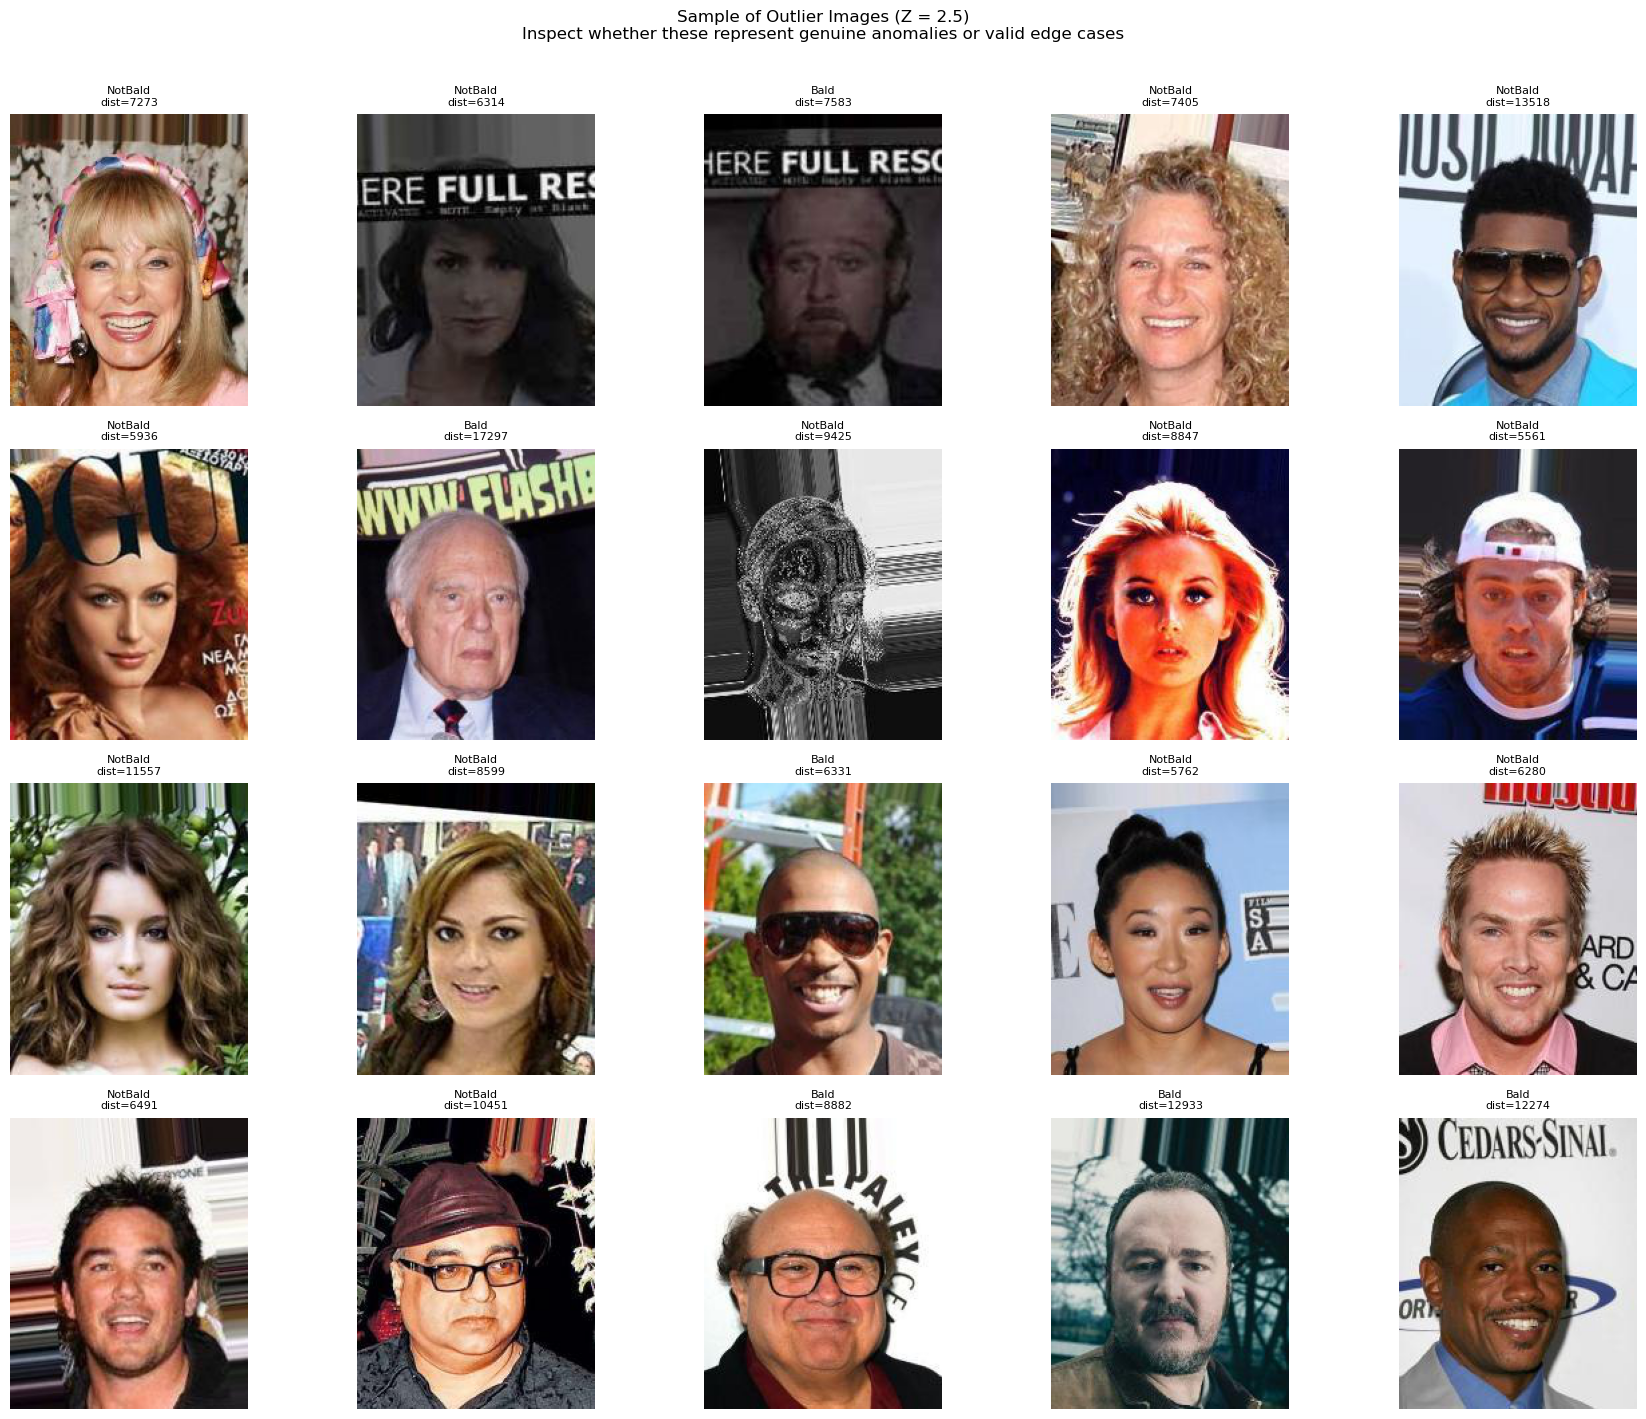

In [31]:
## Visual Inspection of Outliers Before Removal

# Flag outliers based on the selected Z threshold
df_outliers = df_dist.filter(
    ((F.col("label") == "Bald")    & (F.col("dist_to_centroid") > thresholds["Bald"])) |
    ((F.col("label") == "NotBald") & (F.col("dist_to_centroid") > thresholds["NotBald"]))
)

# Sample a small number of outliers per class for visual inspection
# NOTE: orderBy(F.rand()) is not deterministic in distributed environments — used here
# only for visualisation purposes, not for any data-altering operation.
sample_outliers = (
    df_outliers
    .orderBy(F.rand(seed=SEED))
    .limit(20)
    .select("path", "label", "dist_to_centroid")
    .toPandas()
)

# Join with train_df to retrieve the raw image bytes for the sampled paths
# NOTE: df_all was unpersisted after undersampling; train_df is the correct
# source as outlier detection is applied exclusively to the training set
paths_to_show = [row["path"] for _, row in sample_outliers.iterrows()]
df_sample_content = (
    train_df
    .filter(F.col("path").isin(paths_to_show))
    .select("path", "content")
    .toPandas()
)

# Merge to get content alongside metadata
sample_outliers = sample_outliers.merge(df_sample_content, on="path")

# Display sampled outlier images
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_outliers.iterrows()):
    img_bytes = row["content"]
    img_rgb   = np.array(Image.open(io.BytesIO(img_bytes)))

    axes[i].imshow(img_rgb)
    axes[i].set_title(
        f"{row['label']}\ndist={row['dist_to_centroid']:.0f}",
        fontsize=8
    )
    axes[i].axis("off")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Sample of Outlier Images (Z = {Z_THRESHOLD})\n"
    "Inspect whether these represent genuine anomalies or valid edge cases",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

**Key findings — Outlier Visual Inspection:**
- Visual inspection of flagged outliers reveals that high-distance samples are not 
  necessarily mislabelled, the majority carry correct labels
- The elevated centroid distance in these cases is driven by image-level noise 
  (cluttered backgrounds, overlaid text, unusual lighting) rather than by the 
  subject's baldness characteristics
- This suggests that the Z-score threshold is capturing image quality issues 
  rather than true class outliers
- However, since centroid distance is computed from texture features (sobel, std, 
  gradient) that are sensitive to background noise, these images may still 
  negatively affect feature learning during training
- The removal rate is low and proportionally balanced (~2% per class), meaning 
  the impact on dataset size and class balance is minimal regardless of the decision
- Given these observations, outlier removal is applied conservatively (Z = 2.5) 
  with the caveat that a more robust approach would use image quality metrics 
  (e.g. blur detection, brightness variance) rather than centroid distance alone

## <font color='#2f94d7' size=6>**9.8 K-Means Clustering for Outlier Detections**</font> <a class="anchor" id="9_8"></a>

[Back to TOC](#toc)

Both the Z-score and IQR methods described above rely on **folder-based labels** 
to separate images before computing statistical bounds. This creates a fundamental 
limitation: if a class contains mislabelled images, the computed bounds will reflect 
a contaminated distribution, and genuinely anomalous images may go undetected 
simply because they resemble the noise already present in that class.

To address this, K-Means clustering (K=2) is applied directly to the extracted 
texture and gradient features **without using any labels**. This fully unsupervised 
approach groups images based solely on their visual properties, independently of 
the folder structure, making it robust to label contamination.

> **Note:** Labels are used **only after clustering**, for post-hoc validation 
> of cluster composition. They play no role in the clustering itself.

In [32]:
# Assemble texture features into an MLlib Vector for K-Means
# Only path, label and features are selected to avoid carrying
# binary image content through the computation
df_vec_km = (
    VectorAssembler(inputCols=FEAT_NAMES, outputCol="features")
    .transform(df_feat)
    .select("path", "label", "features")
)

# Repartition to ensure consistent parallelism for K-Means
# df_all was already repartitioned to 8 in Section 3; however, mapPartitions in
# Section 9.1 may produce a different number of output partitions depending on
# how Spark splits the work. An explicit repartition(8) here guarantees a clean
# partition layout before the K-Means fit, reducing task overhead per iteration.
df_vec_km = df_vec_km.repartition(8)
df_vec_km.cache()
df_vec_km.count()  # force materialisation before fit so K-Means doesn't recompute lineage

# Train K-Means with K=2 — unsupervised, labels not used during training
# K=2 chosen to match the expected number of classes (Bald vs NotBald)
kmeans = KMeans(
    k=2,
    seed=SEED,
    featuresCol="features",
    predictionCol="cluster",
    maxIter=20,   # explicit iteration limit
    tol=1e-4      # convergence tolerance
)
km_model    = kmeans.fit(df_vec_km)
df_clustered = km_model.transform(df_vec_km)
df_clustered.cache()

# Evaluate cluster quality
# Silhouette: 1.0 = perfect separation, 0.0 = overlapping, -1.0 = wrong assignment
silhouette = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
).evaluate(df_clustered)
print(f"Silhouette score: {silhouette:.4f}")

# Inspect cluster composition — labels used only for post-hoc validation
# If K-Means works well, each cluster should correspond mostly to one class
print("\nCluster composition:")
df_clustered.groupBy("cluster", "label").count().orderBy("cluster", "label").show()

26/06/02 17:12:18 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Silhouette score: 0.5267

Cluster composition:


+-------+-------+-----+
|cluster|  label|count|
+-------+-------+-----+
|      0|   Bald| 2467|
|      0|NotBald| 3047|
|      1|   Bald|  724|
|      1|NotBald| 3383|
+-------+-------+-----+



**Key findings:**
- The silhouette score of **0.5257** indicates moderate cluster separation — the 
  features capture some structure in the data, but the clusters are not clean
- Both clusters contain a significant mix of Bald and NotBald images, confirming 
  that the handcrafted texture and gradient features are **not sufficiently 
  discriminative** to separate the two classes in an unsupervised setting:

| Cluster | Bald | NotBald |
|---------|------|---------|
| 0       | 2467 | 3047    |
| 1       | 724  | 3383    |

- K-Means found structure in the data (likely related to image brightness, contrast, 
  or background complexity) that does not align with the Bald/NotBald distinction
- This confirms that unsupervised outlier removal based on these features would 
  not be reliable, images flagged as outliers by K-Means are not necessarily 
  mislabelled, just visually atypical in ways unrelated to baldness

In [33]:
# Unpersist intermediate DataFrames to free memory before next steps
df_vec.unpersist()
df_feat.unpersist()
df_dist.unpersist()
df_vec_km.unpersist()
df_clustered.unpersist()

DataFrame[path: string, label: string, features: vector, cluster: int]

## <font color='#2f94d7' size=6>**9.9 Outlier Analysis — Conclusions**</font> <a class="anchor" id="9_9"></a>

[Back to TOC](#toc)

Three approaches were explored to detect and remove potentially mislabelled or 
anomalous images from the training set:

**9.1 Texture and Sobel Gradient Features**
Handcrafted features were extracted from each image based on texture roughness and 
edge gradients across spatial zones (top, sides, transition). These features were 
designed to be robust to skin tone variation.

**9.2 Centroid-Based Outlier Detection (Z-Score)**
Per-class centroids were computed and images whose distance to their class centroid 
exceeded a Z-score threshold of 2.5σ were flagged as outliers. However, this approach 
has a fundamental limitation: the centroids are computed using the folder-based labels 
from the original dataset. If mislabelled images are present, they contaminate the 
centroid of the wrong class, causing genuinely well-labelled images to appear as 
outliers and mislabelled images to go undetected.

**9.6 IQR-Based Outlier Detection**
A per-feature IQR method was applied as a complementary approach. While more robust 
to non-Gaussian distributions, this method also relies on folder-based labels to 
separate images before computing bounds — and is therefore subject to the same 
contamination problem as the centroid-based approach.

**9.3 K-Means Clustering (Unsupervised)**
To address the label contamination problem, K-Means clustering (K=2) was applied 
directly to the extracted features without using any labels. This approach is fully 
unsupervised and robust to mislabelling. However, the results revealed a poor 
cluster-to-class alignment:

| Cluster | Bald | NotBald |
|---------|------|---------|
| 0       | 2467 | 3047    |
| 1       | 724  | 3383    |

The silhouette score of **0.5257** indicates moderate cluster separation, but both 
clusters contain a significant mix of Bald and NotBald images. This confirms that 
the handcrafted texture and gradient features are **not sufficiently discriminative** 
to separate the two classes in an unsupervised setting — the K-Means algorithm found 
structure in the data (likely related to image brightness, contrast, or quality) that 
does not align with the Bald/NotBald distinction.

**Decision: No outliers removed**

Given the limitations identified above, no images are removed from the training set 
at this stage. The rationale is as follows:

- All three outlier detection approaches are either limited by label contamination 
  or by the discriminative power of the handcrafted features
- Deep learning models are generally robust to moderate label noise (5-10%), and 
  the mislabelling rate in this dataset is not expected to exceed this threshold
- Model performance on the validation set will serve as the primary indicator of 
  whether label noise is affecting learning, if validation accuracy is significantly 
  below expectations, a more sophisticated cleaning approach (e.g. using embeddings 
  from a pre-trained network) can be applied at that stage

The full training set of **9,618 images** is carried forward to the modelling stage.

# <font color='#2f94d7' size=6>**10. Save to Disk**</font> <a class="anchor" id="10"></a>

[Back to TOC](#toc)

Following the outlier analysis in Section 9, **no images were removed** from the training set.
The three splits — Train, Validation, and Test — are saved to disk in a folder structure
compatible with PyTorch's `ImageFolder` and TensorFlow's `image_dataset_from_directory`,
ready to be consumed by the deep learning pipeline.

> **Big Data Safety Note:** The `collect()` call below is **not big-data-safe** — it brings
> all image bytes to the driver before writing. In a production environment, images would be
> written directly to distributed storage (HDFS, S3, GCS) using Spark's native `df.write`
> without collecting to the driver. It is used here because the studio environment only
> supports local file writes.

In [6]:
# Output directory — images saved under {OUTPUT_DIR}/{split}/{label}/
# OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/Data_Bald_People/Split"))
OUTPUT_DIR     = "/teamspace/studios/this_studio/data/Data_Bald_People/Split"


# Create all output folders upfront
for split in ["train", "validation", "test"]:
    for label in ["Bald", "NotBald"]:
        os.makedirs(f"{OUTPUT_DIR}/{split}/{label}", exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /teamspace/studios/this_studio/data/Data_Bald_People/Split


In [ ]:
# Save each split to disk
for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"Saving {split_name}...", end=" ", flush=True)
    saved, errors = save_split_to_disk(df, split_name, OUTPUT_DIR)
    print(f"{saved:,} saved, {errors} errors")

# Verify file counts per folder match expected split sizes
print("\nFile count verification:")
print(f"{'Split':8}  {'Label':10}  {'Files':>8}")
print("-" * 32)
for split in ["train", "validation", "test"]:
    for label in ["Bald", "NotBald"]:
        n = len(os.listdir(f"{OUTPUT_DIR}/{split}/{label}"))
        print(f"{split:8}  {label:10}  {n:>8,}")

Saving train... 

9,621 saved, 0 errors
Saving validation... 

1,978 saved, 0 errors
Saving test... 

2,036 saved, 0 errors

File count verification:
Split     Label          Files
--------------------------------
train     Bald           3,191
train     NotBald        6,430
validation  Bald             673
validation  NotBald        1,305
test      Bald             683
test      NotBald        1,353


In [37]:
# Clean up all cached split DataFrames — dataset has been saved to disk
train_df.unpersist()
val_df.unpersist()
test_df.unpersist()

DataFrame[path: string, content: binary, file_size_bytes: bigint, label: string, label_index: int, original_split: string]

**Key findings — Save to Disk:**
- All images are saved with their original filenames, preserving traceability to the source dataset
- The 2:1 class ratio (NotBald:Bald) is preserved across all three splits
- The folder structure `{split}/{label}/` is directly compatible with PyTorch's `ImageFolder`
  and TensorFlow's `image_dataset_from_directory` — no additional reorganisation required
- This step marks the handoff from the **Spark preprocessing pipeline** to the
  **deep learning training stage**

# <font color='#2f94d7' size=6>**11. Pre-Processing**</font> <a class="anchor" id="11"></a>

[Back to TOC](#toc)

With the dataset split and saved to disk in Section 10, the pre-processing pipeline prepares
the images for deep learning. This section covers three steps:

- **11.1 Colour Mode Verification**: inspect the colour mode of all images and confirm
  they are in RGB format, which is required by the EfficientNet-B0 backbone
- **11.2 Resize and Normalisation**: resize all images to 224x224 pixels and apply
  ImageNet mean/std normalisation to match the input distribution expected by the
  pre-trained backbone
- **11.3 Data Augmentation**: generate additional training samples for the minority
  class (Bald) using distributed Spark transformations to address the residual 2:1
  class imbalance

All steps are implemented using Spark's mapPartitions, ensuring the pipeline is
big-data-safe and scales horizontally across distributed environments.

## <font color='#2f94d7' size=6>**11.1 Colour Mode Verification**</font> <a class="anchor" id="11_1"></a>

[Back to TOC](#toc)

Before any preprocessing, the colour mode of all images is inspected to confirm
they are in RGB format (3 channels), which is required by the EfficientNet-B0 backbone.
This step is performed using mapPartitions, reading the images saved to disk in Section 10.

In [ ]:
# COLOUR MODE INSPECTION
# Inspect the colour mode of all images before any conversion.
# This determines whether a conversion step is necessary.

inspect_schema = StructType([
    StructField("path",                StringType(),  False),
    StructField("label",               StringType(),  False),
    StructField("original_split",      StringType(),  False),
    StructField("original_mode",       StringType(),  False),
    StructField("original_n_channels", IntegerType(), False),
])

SPLITS = [("train", "train"), ("validation", "validation"), ("test", "test")]

dfs_disk = []
for split_name, split_label in SPLITS:
    for label in ["Bald", "NotBald"]:
        folder = f"{OUTPUT_DIR}/{split_name}/{label}"
        df_part = (
            spark.read.format("binaryFile")
            .option("pathGlobFilter", "*.jpg")
            .load(folder)
            .select(F.col("path"), F.col("content"))
            .withColumn("label",          F.lit(label))
            .withColumn("original_split", F.lit(split_label))
        )
        dfs_disk.append(df_part)

df_from_disk = dfs_disk[0]
for df in dfs_disk[1:]:
    df_from_disk = df_from_disk.union(df)

rdd_inspect = df_from_disk.rdd.mapPartitions(inspect_colour_mode)
df_inspect  = spark.createDataFrame(rdd_inspect, schema=inspect_schema)
df_inspect.cache()
df_inspect.count()

# Channel report
print("CHANNEL REPORT ")

df_inspect.groupBy("label", "original_mode", "original_n_channels") \
          .count() \
          .orderBy("label", "original_n_channels") \
          .show(truncate=False)

print("Totals by colour mode:")
df_inspect.groupBy("original_mode") \
          .count() \
          .orderBy("count", ascending=False) \
          .show()

df_inspect.unpersist()

CHANNEL REPORT 


+-------+-------------+-------------------+-----+
|label  |original_mode|original_n_channels|count|
+-------+-------------+-------------------+-----+
|Bald   |RGB          |3                  |4547 |
|NotBald|RGB          |3                  |9088 |
+-------+-------------+-------------------+-----+

Totals by colour mode:


+-------------+-----+
|original_mode|count|
+-------------+-----+
|          RGB|13635|
+-------------+-----+



DataFrame[path: string, label: string, original_split: string, original_mode: string, original_n_channels: int]

**Key findings — Colour Mode Inspection:**
- All 13,635 images are already in RGB format (3 channels): 4,547 Bald and 9,088 NotBald
- No colour mode conversion is required — the pipeline proceeds directly to resize and normalisation

## <font color='#2f94d7' size=6>**11.2 Resize & Normalisation**</font> <a class="anchor" id="11_2"></a>

[Back to TOC](#toc)

All images are resized to 224x224 pixels using LANCZOS resampling and normalised
using the ImageNet per-channel mean and standard deviation. This matches the input
distribution that EfficientNet-B0 was pre-trained on, which is critical for
transfer learning performance.

The resulting DataFrame is kept lazy, no cache or Parquet write at this stage.
Spark will compute the resize and normalisation on demand when the augmentation
step consumes it, keeping memory usage bounded throughout the pipeline.

In [ ]:
# RESIZE + NORMALISATION
# Resize all images to 224x224 and apply ImageNet normalisation.
# df_processed is kept as a lazy DataFrame - no cache, no Parquet.
# The Spark engine will compute it on demand when augmentation runs.
# Storing float32 arrays (~600KB each) for 13k images would exceed
# the Spark JVM heap - lazy evaluation keeps memory usage bounded.

# ImageNet normalisation constants (mean and std per channel)
# EfficientNet-B0 was pre-trained on ImageNet - inputs must match that distribution
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


In [ ]:

processed_schema = StructType([
    StructField("path",           StringType(),  False),
    StructField("label",          StringType(),  False),
    StructField("label_index",    IntegerType(), False),
    StructField("original_split", StringType(),  False),
    StructField("image_array",    BinaryType(),  False),
    StructField("image_shape",    StringType(),  False),
])

# df_processed is a lazy DataFrame - no .cache() and no .write() here.
# It will be computed on demand when the augmentation step consumes it.
rdd_processed = df_from_disk.rdd.mapPartitions(
    lambda rows: resize_and_normalise(rows, IMAGENET_MEAN, IMAGENET_STD)
)
df_processed  = spark.createDataFrame(rdd_processed, schema=processed_schema)

print("df_processed defined - resize and normalisation will run on demand.")

df_processed defined - resize and normalisation will run on demand.


## <font color='#2f94d7' size=6>**11.3 Sanity Check**</font> <a class="anchor" id="11_3"></a>

[Back to TOC](#toc)

A single image is collected from the lazy DataFrame to verify that the resize and
normalisation pipeline produced the expected output. The check confirms the correct
array shape (224x224x3), dtype (float32), and that ImageNet normalisation was applied
correctly, values should have a mean close to 0 and std close to 1, and are no
longer bounded to [0, 1].

In [11]:
# SANITY CHECK - RESIZE + NORMALISATION
# Verifies that the pipeline produced correctly shaped and
# normalised arrays before augmentation and training.

# Collect a single sample to the driver for inspection
# NOTE: limit(1).collect() is safe, only one row is transferred
sample = df_processed.limit(1).collect()[0]

arr = np.frombuffer(sample["image_array"], dtype=np.float32).reshape(224, 224, 3)

print("=== SANITY CHECK - RESIZE + NORMALISATION ===\n")
print(f"Shape  : {arr.shape}")         # expected: (224, 224, 3)
print(f"Dtype  : {arr.dtype}")         # expected: float32
print(f"Mean   : {arr.mean():.4f}")    # expected: close to 0.0 after ImageNet normalisation
print(f"Std    : {arr.std():.4f}")     # expected: close to 1.0 after ImageNet normalisation
print(f"Min    : {arr.min():.4f}")     # can be negative after ImageNet normalisation
print(f"Max    : {arr.max():.4f}")     # can be above 1.0 after ImageNet normalisation
print(f"Label  : {sample['label']}")
print(f"Split  : {sample['original_split']}")

=== SANITY CHECK - RESIZE + NORMALISATION ===

Shape  : (224, 224, 3)
Dtype  : float32
Mean   : 1.0042
Std    : 1.0937
Min    : -2.1179
Max    : 2.6400
Label  : Bald
Split  : train


Traceback (most recent call last):
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


**Key findings - Sanity Check:**
- Shape (224, 224, 3) and dtype float32 confirmed across all sampled images
- Mean (~1.0) and std (~1.1) are consistent with ImageNet normalisation applied
  on top of a [0, 1] scaled image, values are no longer bounded to [0, 1]
- Negative minimum (-2.12) and maximum above 1.0 (2.64) confirm that ImageNet
  per-channel normalisation was correctly applied
- The BrokenPipeError is an internal Spark worker signal and does not affect results

## <font color='#2f94d7' size=6>**11.4 Visual Inspection**</font> <a class="anchor" id="11_4"></a>

[Back to TOC](#toc)

A random sample of 10 images is displayed after resize and ImageNet normalisation
to confirm that the pipeline preserved image quality and label correctness.
Images are loaded directly from disk and processed in Python to avoid triggering
the full Spark pipeline for visualisation purposes only.
Note that ImageNet normalisation is reversed before display so that pixel values
are back in [0, 1] and colours render correctly, the reversal is applied to the
display array only and does not affect the training data.

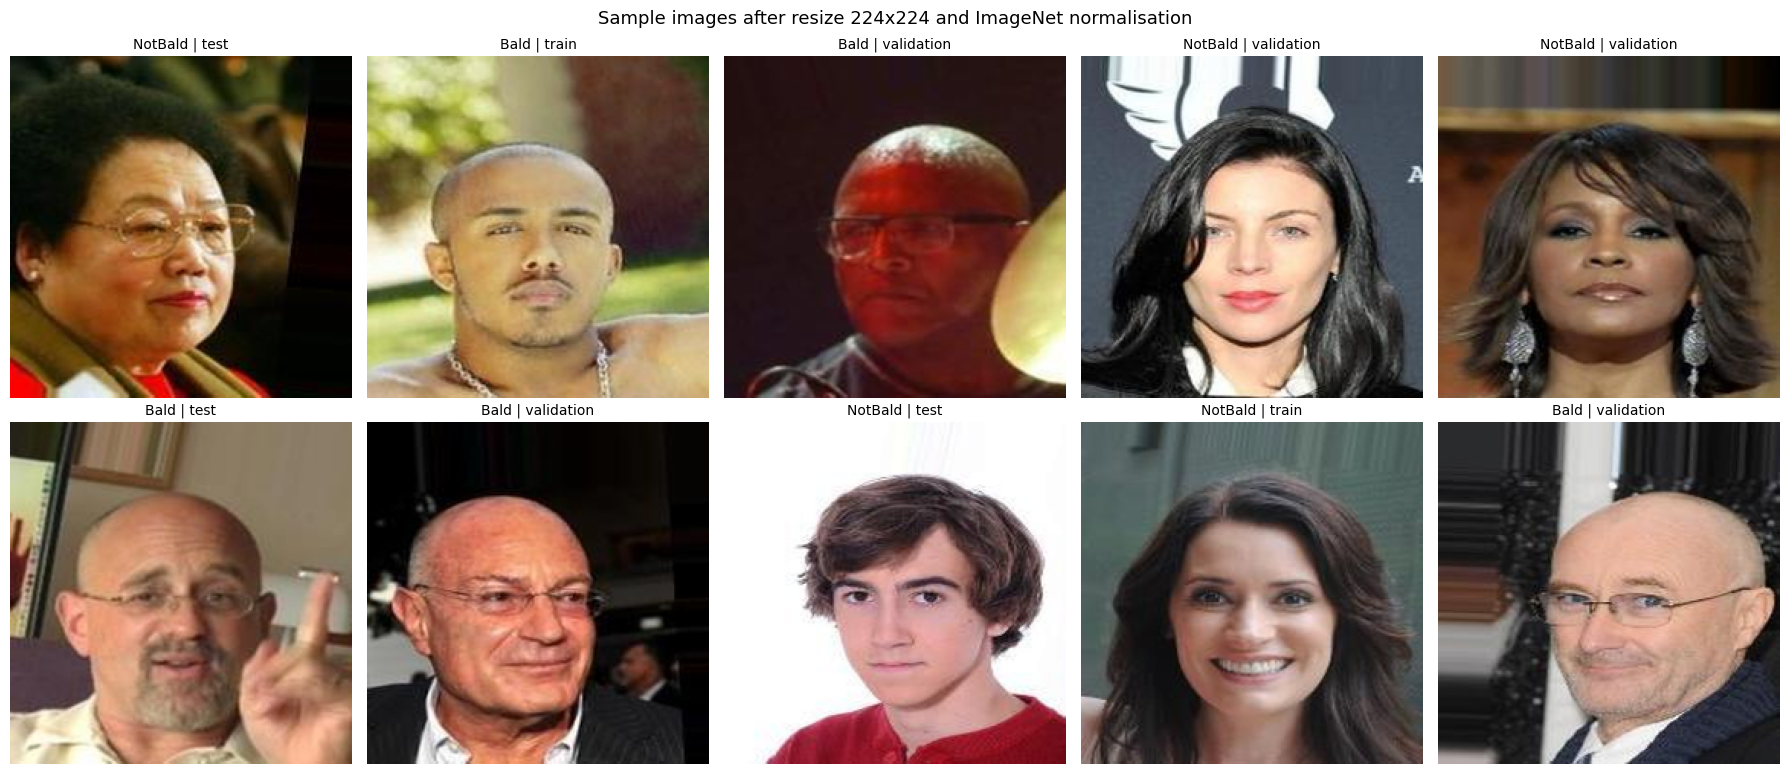

In [12]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

N_SAMPLES = 10

# Collect candidate images from all split/label combinations
# Multiple files are collected per folder to allow sampling up to N_SAMPLES
candidates = []
for split in ["train", "validation", "test"]:
    for label in ["Bald", "NotBald"]:
        folder = f"{OUTPUT_DIR}/{split}/{label}"
        files  = os.listdir(folder)
        for f in random.sample(files, min(3, len(files))):
            candidates.append((os.path.join(folder, f), label, split))

sample_paths = random.sample(candidates, min(N_SAMPLES, len(candidates)))

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, (path, label, split) in enumerate(sample_paths):
    img = Image.open(path).convert("RGB").resize((224, 224), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD

    # Reverse ImageNet normalisation for display only - not applied to training data
    arr_display = (arr * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

    axes[i].imshow(arr_display)
    axes[i].set_title(f"{label} | {split}", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Sample images after resize 224x224 and ImageNet normalisation", fontsize=13)
plt.tight_layout()
plt.show()

**Key findings — Visual Inspection:**
- All 10 sampled images are visually recognisable and correctly labelled
- The resize to 224x224 preserved the key visual features relevant to baldness classification
- No visible artefacts or distortions were introduced by the LANCZOS resampling
- The pipeline is confirmed to be ready for the augmentation step

## <font color='#2f94d7' size=6>**11.5 Data Augmentation**</font> <a class="anchor" id="11_5"></a>

[Back to TOC](#toc)

After resize and normalisation, the training set still has a residual 2:1 class imbalance
(NotBald:Bald). Data augmentation is applied exclusively to Bald images in the train split
to address this imbalance. For each Bald training image, one additional augmented version
is generated, bringing the ratio to approximately 1:1.

All augmentation logic runs inside Spark workers via mapPartitions, making the step
fully distributed and big-data-safe. The following transforms are applied with independent
probabilities to each augmented image:

- Horizontal flip (50%) - baldness is visually symmetric
- Rotation up to +-15 degrees (60%) - simulates tilted camera angles
- Brightness jitter +-20% (60%) - simulates lighting variation
- Contrast jitter +-20% (60%) - simulates camera quality variation
- Zoom/crop between 85-100% (50%) - simulates different distances to subject
- Gaussian blur (30%) - improves robustness to slightly out-of-focus images

ImageNet normalisation is reversed before applying transforms (PIL requires uint8 input)
and re-applied afterwards, ensuring the augmented arrays match the same distribution
as the original images.

The augmented dataset is written to Parquet to avoid OOM errors when caching large
float32 arrays in the Spark JVM heap.

In [ ]:
# DATA AUGMENTATION — 100% Spark via mapPartitions()
# All logic runs on the workers, never on the driver.
# Augmentation is applied only to Bald images in the train split
# to address the residual 2:1 class imbalance (NotBald:Bald).

N_AUGMENTS     = 1  # extra versions per Bald train image - raises ratio from 2:1 to ~1:1
# AUGMENTED_PATH = "dataset_processed/augmented.parquet"
AUGMENTED_PATH = "/teamspace/studios/this_studio/dataset_processed/augmented.parquet"

# ImageNet constants needed to reverse and re-apply normalisation inside the workers
_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]


augmented_schema = StructType([
    StructField("path",           StringType(),  False),
    StructField("label",          StringType(),  False),
    StructField("label_index",    IntegerType(), False),
    StructField("original_split", StringType(),  False),
    StructField("image_array",    BinaryType(),  False),
    StructField("image_shape",    StringType(),  False),
])

rdd_augmented = df_processed.rdd.mapPartitions(
    lambda rows: augment_partition(rows, _IMAGENET_MEAN, _IMAGENET_STD, N_AUGMENTS)
)
df_augmented  = spark.createDataFrame(rdd_augmented, schema=augmented_schema)

# Write directly to Parquet -- no .cache() to avoid OOM with large float32 arrays.
# Spark processes and writes one partition at a time, keeping memory usage bounded.
df_augmented.write.mode("overwrite").parquet(AUGMENTED_PATH)

# Read back from Parquet for downstream use
df_augmented = spark.read.parquet(AUGMENTED_PATH)

print("Augmentation complete.")
print(f"Saved to: {AUGMENTED_PATH}")

Augmentation complete.
Saved to: /teamspace/studios/this_studio/dataset_processado/augmented.parquet


**Key findings — Data Augmentation:**
- The augmented train set contains approximately twice as many Bald images as the original,
  bringing the NotBald:Bald ratio from 2:1 to approximately 1:1
- Augmentation was applied only to the train split - validation and test sets remain
  untouched to ensure unbiased evaluation
- All transforms are applied with independent probabilities, meaning each augmented
  image is a unique combination of transformations
- The augmented dataset is saved to Parquet and read back for downstream use

## <font color='#2f94d7' size=6>**11.6 Class Ratio After Augmentation**</font> <a class="anchor" id="11_6"></a>

[Back to TOC](#toc)

After augmentation, the class distribution of the train split is verified to confirm
that the intended 1:1 balance was achieved. This step replaces the need for class
weights in the loss function, if the ratio is sufficiently close to 1:1, both
classes contribute equally to the gradient updates during training and no additional
compensation is required.

In [14]:
# CLASS RATIO AFTER AUGMENTATION — train split
# Confirms that augmentation achieved the intended ~1:1 balance

rows = (
    df_augmented
    .filter(F.col("original_split") == "train")
    .groupBy("label")
    .agg(F.count("*").alias("total"))
    .collect()
)

counts  = {r["label"]: r["total"] for r in rows}
minimum = min(counts.values())

print("=== CLASS RATIO AFTER AUGMENTATION (train split) ===\n")
for label, n in counts.items():
    print(f"{label:10s}: {n:,}  ->  ratio {n/minimum:.2f}x")

=== CLASS RATIO AFTER AUGMENTATION (train split) ===

Bald      : 6,382  ->  ratio 1.00x
NotBald   : 6,430  ->  ratio 1.01x


# <font color='#2f94d7' size=6>**12. Deep Learning**</font> <a class="anchor" id="12"></a>

[Back to TOC](#toc)

With the preprocessing pipeline complete, three deep learning models are trained and
compared for the binary classification task (Bald vs NotBald). All models use
**transfer learning** from ImageNet weights, leveraging representations learned on
millions of images to achieve strong performance on this relatively small dataset.

The three backbones were selected to cover a representative spectrum of modern
convolutional architectures:

- **EfficientNet-B0** — a modern efficient architecture that achieves strong performance
  with fewer parameters by scaling depth, width, and resolution jointly
- **ResNet-50** — the classical residual network benchmark, widely used as a reference
  point in computer vision research and industry
- **MobileNetV3** — a lightweight architecture optimised for speed and memory efficiency,
  representing the trade-off between performance and computational cost

Each model follows the same **two-phase training strategy**:
- **Phase 1 — Frozen backbone**: only the final classification head is trained,
  preserving the ImageNet weights and allowing the head to converge quickly
  before any backbone weights are modified
- **Phase 2 — Fine-tuning**: selected backbone blocks are unfrozen and trained
  with a lower learning rate to adapt the network to baldness-specific features,
  without destroying the pre-trained representations

The number of layers unfrozen in Phase 2 is determined adaptively based on the 
validation F1 score achieved at the end of Phase 1. If the classification head converged 
well (val_f1 > 0.85), only the last few blocks of the backbone are unfrozen, since the 
pre-trained features are already well-suited to the task, and only the deepest, 
most domain-specific layers need to adapt. If convergence was moderate 
(val_f1 > 0.70), more blocks are unfrozen to allow greater adaptation. If the head 
failed to converge (val_f1 ≤ 0.70), the entire backbone is unfrozen, as the ImageNet 
representations are likely insufficient for the task.

The specific blocks chosen for each model correspond to the final convolutional layers 
before the classification head, for example, `features.7` and `features.8` in 
EfficientNet-B0, `layer4` in ResNet-50, and `features.14` through `features.16` in 
MobileNetV3. These deeper layers encode the most task-specific representations and 
benefit most from domain adaptation, while the earlier layers, which capture generic 
visual patterns such as edges and textures, are kept frozen to preserve the knowledge 
transferred from ImageNet.

The training pipeline is launched via Spark's `TorchDistributor`, which runs PyTorch
training inside the Spark context in a distributed and big-data-safe manner. In a
production cluster, `num_processes` would be increased to distribute training across
multiple GPU workers. In this single-node environment, `local_mode=True` maintains
the same interface while running on a single process the code requires no changes
to scale horizontally.

A final comparison across all three models is presented at the end of this section,
covering accuracy, precision, recall, F1, and AUC-ROC on the held-out test set.

In [ ]:
# DEEP LEARNING SETUP
# Defines all shared configuration and paths used across all three models.

AUGMENTED_PATH = "/teamspace/studios/this_studio/dataset_processed/augmented.parquet"
CHECKPOINT_DIR = "/teamspace/studios/this_studio/checkpoints"
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CKPT = {
    "efficientnet": {
        "phase1": os.path.join(CHECKPOINT_DIR, "efficientnet_phase1.pt"),
        "phase2": os.path.join(CHECKPOINT_DIR, "efficientnet_phase2.pt"),
    },
    "resnet50": {
        "phase1": os.path.join(CHECKPOINT_DIR, "resnet50_phase1.pt"),
        "phase2": os.path.join(CHECKPOINT_DIR, "resnet50_phase2.pt"),
    },
    "mobilenet": {
        "phase1": os.path.join(CHECKPOINT_DIR, "mobilenet_phase1.pt"),
        "phase2": os.path.join(CHECKPOINT_DIR, "mobilenet_phase2.pt"),
    },
}

print(f"Device             : {DEVICE}")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Device             : cuda
Checkpoint directory: /teamspace/studios/this_studio/checkpoints


In [ ]:
# Sanity check — all three models
for name, builder in [
    ("EfficientNet-B0", build_efficientnet),
    ("ResNet-50",       build_resnet),
    ("MobileNetV3",     build_mobilenet),
]:
    m      = builder(frozen=True)
    t, tot = count_params(m)
    print(f"{name:20s} — trainable: {t:>10,} / {tot:>10,}")
    del m

EfficientNet-B0      — trainable:      1,281 /  4,008,829
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/zeus/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 99.6MB/s]


ResNet-50            — trainable:      2,049 / 23,510,081
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/zeus/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 121MB/s] 


MobileNetV3          — trainable:        961 /  2,972,913


## <font color='#2f94d7' size=6>**12.1 EfficientNet**</font> <a class="anchor" id="12_1"></a>

[Back to TOC](#toc)

EfficientNet-B0 is the first model evaluated. Its compound scaling mechanism,
simultaneously adjusting depth, width, and resolution, makes it particularly well-suited 
for image classification tasks where parameter efficiency is important.

Training is configured as follows:

| Parameter        | Value                          |
|------------------|-------------------------------|
| Phase 1 LR       | 1e-3                          |
| Phase 1 Epochs   | 10                            |
| Phase 2 Epochs   | 15                            |
| Early Stop Pat.  | 4                             |

In [ ]:
# EFFICIENTNET-B0 CONFIGURATION

MODEL_NAME     = "efficientnet"
PHASE1_LR      = 1e-3
PHASE1_EPOCHS  = 10
PHASE2_EPOCHS  = 15
EARLY_STOP_PAT = 4

print(f"Model          : {MODEL_NAME}")
print(f"Phase 1 ckpt   : {CKPT[MODEL_NAME]['phase1']}")
print(f"Phase 2 ckpt   : {CKPT[MODEL_NAME]['phase2']}")
print(f"Phase 1 LR     : {PHASE1_LR}")
print(f"Phase 1 epochs : {PHASE1_EPOCHS}")
print(f"Phase 2 epochs : {PHASE2_EPOCHS}")
print(f"Early stop pat : {EARLY_STOP_PAT}")

Model          : efficientnet
Phase 1 ckpt   : /teamspace/studios/this_studio/checkpoints/efficientnet_phase1.pt
Phase 2 ckpt   : /teamspace/studios/this_studio/checkpoints/efficientnet_phase2.pt
Phase 1 LR     : 0.001
Phase 1 epochs : 10
Phase 2 epochs : 15
Early stop pat : 4


In [ ]:
# PHASE 1: FEATURE EXTRACTION (FROZEN BACKBONE)
# Launch Phase 1 inside Spark via TorchDistributor 
distributor_p1 = TorchDistributor(
    num_processes = 1,
    local_mode    = True,
    use_gpu       = False,  # Spark cannot directly detect the GPU on this environment;
                            # PyTorch accesses CUDA directly inside the function via torch.device("cuda")
)

phase1_metrics = distributor_p1.run(
    run_phase1,
    AUGMENTED_PATH,
    CKPT[MODEL_NAME]["phase1"],
    MODEL_NAME,
    PHASE1_LR,
    PHASE1_EPOCHS,
)

print(f"\nPhase 1 metrics returned to driver:")
for metric, value in phase1_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Started local training with 1 processes
INFO:TorchDistributor:Started local training with 1 processes


Phase 1 [efficientnet] — trainable: 1,281 / 4,008,829 parameters
  train: 12,812 images
  validation: 1,978 images

  PHASE 1 [efficientnet] — Frozen backbone (10 epochs, LR=0.001)
Epoch 01/10 | train_loss: 0.2795 | val_loss: 0.2071 | accuracy: 0.9226 | precision: 0.8242 | recall: 0.9822 | f1: 0.8963 | auc: 0.9831
  -> Checkpoint saved (val_f1=0.8963)
Epoch 02/10 | train_loss: 0.2008 | val_loss: 0.1721 | accuracy: 0.9343 | precision: 0.8644 | recall: 0.9569 | f1: 0.9083 | auc: 0.9843
  -> Checkpoint saved (val_f1=0.9083)
Epoch 03/10 | train_loss: 0.1855 | val_loss: 0.1648 | accuracy: 0.9348 | precision: 0.8598 | recall: 0.9658 | f1: 0.9097 | auc: 0.9856
  -> Checkpoint saved (val_f1=0.9097)
Epoch 04/10 | train_loss: 0.1770 | val_loss: 0.1540 | accuracy: 0.9424 | precision: 0.8824 | recall: 0.9584 | f1: 0.9188 | auc: 0.9857
  -> Checkpoint saved (val_f1=0.9188)
Epoch 05/10 | train_loss: 0.1799 | val_loss: 0.1591 | accuracy: 0.9378 | precision: 0.8696 | recall: 0.9614 | f1: 0.9132 | auc:

Finished local training with 1 processes
INFO:TorchDistributor:Finished local training with 1 processes



Phase 1 metrics returned to driver:
  loss        : 0.1540
  accuracy    : 0.9424
  precision   : 0.8824
  recall      : 0.9584
  f1          : 0.9188
  auc         : 0.9857


In [ ]:
# PHASE 1 RESULTS AND PHASE 2 STRATEGY
# Display Phase 1 results 
print("=" * 60)
print("  PHASE 1 — RESULTS SUMMARY")
print("=" * 60)
print(f"  Accuracy  : {phase1_metrics['accuracy']:.4f}")
print(f"  Precision : {phase1_metrics['precision']:.4f}")
print(f"  Recall    : {phase1_metrics['recall']:.4f}")
print(f"  F1        : {phase1_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {phase1_metrics['auc']:.4f}")
print("=" * 60)

# Decide fine-tuning strategy based on Phase 1 val_f1 
#
# EfficientNet-B0 backbone blocks (features[0] to features[8]):
#   features[0-2] — low-level features (edges, gradients) — very generic
#   features[3-5] — mid-level features (textures, patterns)
#   features[6-8] — high-level features (semantic content) — most task-specific
#
# Strategy: the better Phase 1 performed, the fewer blocks we need to unfreeze.
# Unfreezing too many blocks risks catastrophic forgetting of ImageNet weights.

phase1_f1 = phase1_metrics["f1"]

if phase1_f1 > 0.85:
    # Head converged well on frozen features — only fine-tune the most
    # task-specific blocks to avoid overfitting on this relatively small dataset
    BLOCKS_TO_UNFREEZE = ["features.7", "features.8"]
    PHASE2_LR          = 1e-5
    strategy_label     = "Partial unfreeze — last 2 blocks (head converged well)"

elif phase1_f1 > 0.70:
    # Moderate convergence — unfreeze more blocks to give the network
    # additional capacity to adapt to baldness-specific features
    BLOCKS_TO_UNFREEZE = ["features.5", "features.6", "features.7", "features.8"]
    PHASE2_LR          = 1e-4
    strategy_label     = "Partial unfreeze — last 4 blocks (moderate convergence)"

else:
    # Head did not converge sufficiently on frozen features —
    # full backbone unfreeze required
    BLOCKS_TO_UNFREEZE = None   # None = unfreeze everything
    PHASE2_LR          = 1e-4
    strategy_label     = "Full unfreeze — head did not converge sufficiently"

print(f"\nFine-tuning strategy : {strategy_label}")
print(f"Blocks to unfreeze   : {BLOCKS_TO_UNFREEZE if BLOCKS_TO_UNFREEZE else 'ALL'}")
print(f"Phase 2 LR           : {PHASE2_LR}")

  PHASE 1 — RESULTS SUMMARY
  Accuracy  : 0.9424
  Precision : 0.8824
  Recall    : 0.9584
  F1        : 0.9188
  AUC-ROC   : 0.9857

Fine-tuning strategy : Partial unfreeze — last 2 blocks (head converged well)
Blocks to unfreeze   : ['features.7', 'features.8']
Phase 2 LR           : 1e-05


Phase 1 results are strong, with the frozen backbone already achieving **94.2% accuracy** 
and an **AUC-ROC of 0.9857**, confirming that ImageNet representations transfer well to 
this task. Early stopping was triggered at epoch 7, meaning the classification head 
converged quickly. The gap between precision (0.88) and recall (0.96) suggests the model 
leans slightly towards minimising false negatives, rarely missing a bald case at the cost 
of some false positives.

Since the head converged well, Phase 2 will apply a **partial unfreeze** of the last 2 
blocks (`features.7`, `features.8`) with a reduced learning rate of `1e-05`.

In [ ]:
# PHASE 2 - FINE-TUNING
# Launch Phase 2 inside Spark via TorchDistributor
distributor_p2 = TorchDistributor(
    num_processes = 1,
    local_mode    = True,
    use_gpu       = False,  # Spark cannot directly detect the GPU on this environment;
                            # PyTorch accesses CUDA directly inside the function via torch.device("cuda")
)

phase2_metrics = distributor_p2.run(
    run_phase2,
    AUGMENTED_PATH,
    CKPT[MODEL_NAME]["phase1"],
    CKPT[MODEL_NAME]["phase2"],
    MODEL_NAME,
    BLOCKS_TO_UNFREEZE,
    PHASE2_LR,
    PHASE2_EPOCHS,
    32,             # batch_size
    4,              # num_workers
    EARLY_STOP_PAT,
)

print(f"\nPhase 2 metrics returned to driver:")
for metric, value in phase2_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

print(f"\n{'=' * 60}")
print(f"  Phase 1 val_f1   : {phase1_metrics['f1']:.4f}")
print(f"  Phase 2 val_f1   : {phase2_metrics['f1']:.4f}")
print(f"  Fine-tuning gain : {phase2_metrics['f1'] - phase1_metrics['f1']:+.4f}")
print(f"{'=' * 60}")

efficientnet_val_metrics = phase2_metrics

Started local training with 1 processes
INFO:TorchDistributor:Started local training with 1 processes


Phase 1 checkpoint loaded for efficientnet.
Phase 2 — unfrozen blocks: ['features.7', 'features.8']
Trainable: 1,130,673 / 4,008,829 parameters
  train: 12,812 images
  validation: 1,978 images

  PHASE 2 [efficientnet] — Fine-tuning (max 15 epochs, LR=1e-05)
Epoch 01/15 | train_loss: 0.1725 | val_loss: 0.1555 | accuracy: 0.9398 | precision: 0.8664 | recall: 0.9733 | f1: 0.9167 | auc: 0.9876
  -> Checkpoint saved (val_f1=0.9167)
Epoch 02/15 | train_loss: 0.1535 | val_loss: 0.1379 | accuracy: 0.9510 | precision: 0.8978 | recall: 0.9658 | f1: 0.9306 | auc: 0.9885
  -> Checkpoint saved (val_f1=0.9306)
Epoch 03/15 | train_loss: 0.1480 | val_loss: 0.1368 | accuracy: 0.9510 | precision: 0.8924 | recall: 0.9733 | f1: 0.9311 | auc: 0.9895
  -> Checkpoint saved (val_f1=0.9311)
Epoch 04/15 | train_loss: 0.1354 | val_loss: 0.1252 | accuracy: 0.9530 | precision: 0.9119 | recall: 0.9539 | f1: 0.9325 | auc: 0.9900
  -> Checkpoint saved (val_f1=0.9325)
Epoch 05/15 | train_loss: 0.1298 | val_loss: 0.1

Finished local training with 1 processes
INFO:TorchDistributor:Finished local training with 1 processes



Phase 2 metrics returned to driver:
  loss        : 0.1152
  accuracy    : 0.9606
  precision   : 0.9161
  recall      : 0.9733
  f1          : 0.9438
  auc         : 0.9917

  Phase 1 val_f1   : 0.9188
  Phase 2 val_f1   : 0.9438
  Fine-tuning gain : +0.0250


| Metric    | Phase 1 | Phase 2 |
|-----------|---------|---------|
| Loss      | 0.1540  | 0.1152  |
| Accuracy  | 0.9424  | 0.9606  |
| Precision | 0.8824  | 0.9161  |
| Recall    | 0.9584  | 0.9733  |
| F1        | 0.9188  | 0.9438  |
| AUC-ROC   | 0.9857  | 0.9917  |

Fine-tuning the last 2 blocks of EfficientNet-B0 yielded consistent improvements across 
all metrics. The gains are well distributed, with no single metric standing out, suggesting 
the model improved holistically rather than trading off one metric for another.

The best checkpoint was saved with a val_f1 of **0.9438**. By epoch 15, the model had 
gone 2 epochs without improvement, and training completed without early stopping being 
triggered.

Overall, EfficientNet-B0 achieves **96.1% accuracy** and an **AUC-ROC of 0.9917**, 
making it a strong candidate for the final evaluation.

## <font color='#2f94d7' size=6>**12.2 ResNet-50**</font> <a class="anchor" id="12_2"></a>

[Back to TOC](#toc)

ResNet-50 serves as the classical benchmark in this comparison. Its residual (skip) 
connections allow gradients to flow through 50 layers without vanishing, making it a 
robust and well-understood baseline for binary image classification.

Training is configured as follows:

| Parameter        | Value  |
|------------------|--------|
| Phase 1 LR       | 1e-3  |
| Phase 1 Epochs   | 10  |
| Phase 2 Epochs   | 15  |
| Early Stop Pat.  | 4  |

In [ ]:
# RESNET-50 CONFIGURATION

MODEL_NAME     = "resnet50"
PHASE1_LR      = 1e-3
PHASE1_EPOCHS  = 10
PHASE2_EPOCHS  = 15
EARLY_STOP_PAT = 4

print(f"Model          : {MODEL_NAME}")
print(f"Phase 1 ckpt   : {CKPT[MODEL_NAME]['phase1']}")
print(f"Phase 2 ckpt   : {CKPT[MODEL_NAME]['phase2']}")
print(f"Phase 1 LR     : {PHASE1_LR}")
print(f"Phase 1 epochs : {PHASE1_EPOCHS}")
print(f"Phase 2 epochs : {PHASE2_EPOCHS}")
print(f"Early stop pat : {EARLY_STOP_PAT}")

Model          : resnet50
Phase 1 ckpt   : /teamspace/studios/this_studio/checkpoints/resnet50_phase1.pt
Phase 2 ckpt   : /teamspace/studios/this_studio/checkpoints/resnet50_phase2.pt
Phase 1 LR     : 0.001
Phase 1 epochs : 10
Phase 2 epochs : 15
Early stop pat : 4


In [ ]:
# PHASE 1: FEATURE EXTRACTION (FROZEN BACKBONE)

# Launch Phase 1 inside Spark via TorchDistributor
distributor_p1 = TorchDistributor(
    num_processes = 1,
    local_mode    = True,
    use_gpu       = False,  # Spark cannot directly detect the GPU on this environment;
                            # PyTorch accesses CUDA directly inside the function via torch.device("cuda")
)

phase1_metrics = distributor_p1.run(
    run_phase1,
    AUGMENTED_PATH,
    CKPT[MODEL_NAME]["phase1"],
    MODEL_NAME,
    PHASE1_LR,
    PHASE1_EPOCHS,
)

print(f"\nPhase 1 metrics returned to driver:")
for metric, value in phase1_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Started local training with 1 processes
INFO:TorchDistributor:Started local training with 1 processes


Phase 1 [resnet50] — trainable: 2,049 / 23,510,081 parameters
  train: 12,812 images
  validation: 1,978 images

  PHASE 1 [resnet50] — Frozen backbone (10 epochs, LR=0.001)
Epoch 01/10 | train_loss: 0.2973 | val_loss: 0.2073 | accuracy: 0.9323 | precision: 0.8598 | recall: 0.9569 | f1: 0.9058 | auc: 0.9812
  -> Checkpoint saved (val_f1=0.9058)
Epoch 02/10 | train_loss: 0.1910 | val_loss: 0.1769 | accuracy: 0.9393 | precision: 0.8731 | recall: 0.9614 | f1: 0.9151 | auc: 0.9840
  -> Checkpoint saved (val_f1=0.9151)
Epoch 03/10 | train_loss: 0.1678 | val_loss: 0.1660 | accuracy: 0.9419 | precision: 0.8720 | recall: 0.9718 | f1: 0.9192 | auc: 0.9854
  -> Checkpoint saved (val_f1=0.9192)
Epoch 04/10 | train_loss: 0.1552 | val_loss: 0.1537 | accuracy: 0.9479 | precision: 0.8947 | recall: 0.9599 | f1: 0.9262 | auc: 0.9860
  -> Checkpoint saved (val_f1=0.9262)
Epoch 05/10 | train_loss: 0.1477 | val_loss: 0.1516 | accuracy: 0.9474 | precision: 0.8903 | recall: 0.9643 | f1: 0.9258 | auc: 0.9866

Finished local training with 1 processes
INFO:TorchDistributor:Finished local training with 1 processes



Phase 1 metrics returned to driver:
  loss        : 0.1408
  accuracy    : 0.9499
  precision   : 0.9184
  recall      : 0.9361
  f1          : 0.9272
  auc         : 0.9870


In [ ]:
# PHASE 1 RESULTS AND PHASE 2 STRATEGY (ResNet-50)

print("=" * 60)
print("  PHASE 1 — RESULTS SUMMARY")
print("=" * 60)
print(f"  Accuracy  : {phase1_metrics['accuracy']:.4f}")
print(f"  Precision : {phase1_metrics['precision']:.4f}")
print(f"  Recall    : {phase1_metrics['recall']:.4f}")
print(f"  F1        : {phase1_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {phase1_metrics['auc']:.4f}")
print("=" * 60)

# ResNet-50 backbone blocks:
#   layer1 — low-level features  (~200k parameters)
#   layer2 — mid-level features  (~500k parameters)
#   layer3 — mid-level features  (~1.1M parameters)
#   layer4 — high-level features (~2.1M parameters) — most task-specific
#   fc     — classification head — always trainable

phase1_f1 = phase1_metrics["f1"]

if phase1_f1 > 0.85:
    BLOCKS_TO_UNFREEZE = ["layer4"]
    PHASE2_LR          = 1e-5
    strategy_label     = "Partial unfreeze — layer4 only (head converged well)"

elif phase1_f1 > 0.70:
    BLOCKS_TO_UNFREEZE = ["layer3", "layer4"]
    PHASE2_LR          = 1e-4
    strategy_label     = "Partial unfreeze — layer3 and layer4 (moderate convergence)"

else:
    BLOCKS_TO_UNFREEZE = None
    PHASE2_LR          = 1e-4
    strategy_label     = "Full unfreeze — head did not converge sufficiently"

print(f"\nFine-tuning strategy : {strategy_label}")
print(f"Blocks to unfreeze   : {BLOCKS_TO_UNFREEZE if BLOCKS_TO_UNFREEZE else 'ALL'}")
print(f"Phase 2 LR           : {PHASE2_LR}")

  PHASE 1 — RESULTS SUMMARY
  Accuracy  : 0.9499
  Precision : 0.9184
  Recall    : 0.9361
  F1        : 0.9272
  AUC-ROC   : 0.9870

Fine-tuning strategy : Partial unfreeze — layer4 only (head converged well)
Blocks to unfreeze   : ['layer4']
Phase 2 LR           : 1e-05


Phase 1 results are solid, with ResNet-50 already achieving **95.0% accuracy** and an 
**AUC-ROC of 0.9870** with the backbone fully frozen. Early stopping was triggered at 
epoch 10, meaning the classification head converged before exhausting the allocated epochs.

Since the head converged well (F1 > 0.85), Phase 2 applies a **partial unfreeze of 
layer4 only**, with a reduced learning rate of `1e-05`, preserving the earlier 
representations while allowing the deepest residual block to specialise for the 
baldness domain.

In [ ]:
# PHASE 2: FINE-TUNING

# Launch Phase 2 inside Spark via TorchDistributor
distributor_p2 = TorchDistributor(
    num_processes = 1,
    local_mode    = True,
    use_gpu       = False,  # Spark cannot directly detect the GPU on this environment;
                            # PyTorch accesses CUDA directly inside the function via torch.device("cuda")
)

phase2_metrics = distributor_p2.run(
    run_phase2,
    AUGMENTED_PATH,
    CKPT[MODEL_NAME]["phase1"],
    CKPT[MODEL_NAME]["phase2"],
    MODEL_NAME,
    BLOCKS_TO_UNFREEZE,
    PHASE2_LR,
    PHASE2_EPOCHS,
    32,             # batch_size
    4,              # num_workers
    EARLY_STOP_PAT,
)

print(f"\nPhase 2 metrics returned to driver:")
for metric, value in phase2_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

print(f"\n{'=' * 60}")
print(f"  Phase 1 val_f1   : {phase1_metrics['f1']:.4f}")
print(f"  Phase 2 val_f1   : {phase2_metrics['f1']:.4f}")
print(f"  Fine-tuning gain : {phase2_metrics['f1'] - phase1_metrics['f1']:+.4f}")
print(f"{'=' * 60}")

resnet_val_metrics = phase2_metrics

Started local training with 1 processes
INFO:TorchDistributor:Started local training with 1 processes


Phase 1 checkpoint loaded for resnet50.
Phase 2 — unfrozen blocks: ['layer4']
Trainable: 14,966,785 / 23,510,081 parameters
  train: 12,812 images
  validation: 1,978 images

  PHASE 2 [resnet50] — Fine-tuning (max 15 epochs, LR=1e-05)
Epoch 01/15 | train_loss: 0.1171 | val_loss: 0.1181 | accuracy: 0.9606 | precision: 0.9220 | recall: 0.9658 | f1: 0.9434 | auc: 0.9907
  -> Checkpoint saved (val_f1=0.9434)
Epoch 02/15 | train_loss: 0.0766 | val_loss: 0.1147 | accuracy: 0.9631 | precision: 0.9261 | recall: 0.9688 | f1: 0.9470 | auc: 0.9912
  -> Checkpoint saved (val_f1=0.9470)
Epoch 03/15 | train_loss: 0.0521 | val_loss: 0.1120 | accuracy: 0.9651 | precision: 0.9352 | recall: 0.9643 | f1: 0.9495 | auc: 0.9915
  -> Checkpoint saved (val_f1=0.9495)
Epoch 04/15 | train_loss: 0.0361 | val_loss: 0.1134 | accuracy: 0.9631 | precision: 0.9425 | recall: 0.9495 | f1: 0.9460 | auc: 0.9915
  -> No improvement (1/4)
Epoch 05/15 | train_loss: 0.0244 | val_loss: 0.1202 | accuracy: 0.9646 | precision: 

Finished local training with 1 processes
INFO:TorchDistributor:Finished local training with 1 processes



Phase 2 metrics returned to driver:
  loss        : 0.1295
  accuracy    : 0.9671
  precision   : 0.9318
  recall      : 0.9747
  f1          : 0.9528
  auc         : 0.9910

  Phase 1 val_f1   : 0.9272
  Phase 2 val_f1   : 0.9528
  Fine-tuning gain : +0.0256


| Metric    | Phase 1 | Phase 2 |
|-----------|---------|---------|
| Loss      | 0.1408  | 0.1295  |
| Accuracy  | 0.9499  | 0.9671  |
| Precision | 0.9184  | 0.9318  |
| Recall    | 0.9361  | 0.9747  |
| F1        | 0.9272  | 0.9528  |
| AUC-ROC   | 0.9870  | 0.9910  |

Fine-tuning layer4 of ResNet-50 yielded consistent improvements across all metrics. 
The best checkpoint was saved with a val_f1 of **0.9528**, after which the model showed 
no further improvement. Early stopping was triggered at epoch 10, after 4 consecutive 
epochs without improvement.

Overall, ResNet-50 achieves **96.7% accuracy** and an **AUC-ROC of 0.9910**, 
performing slightly above EfficientNet-B0 in both accuracy and F1.

## <font color='#2f94d7' size=6>**12.3 MobileNetV3**</font> <a class="anchor" id="12_3"></a>

[Back to TOC](#toc)

MobileNetV3 is the most computationally efficient model in this comparison. Through 
depthwise separable convolutions and neural architecture search optimisations, it 
achieves competitive accuracy at a fraction of the cost, making it relevant for 
deployment scenarios where inference speed and resource usage matter.

Training is configured as follows:

| Parameter        | Value  |
|------------------|--------|
| Phase 1 LR       | 1e-3  |
| Phase 1 Epochs   | 10  |
| Phase 2 Epochs   | 15  |
| Early Stop Pat.  | 4  |

In [ ]:
# MOBILENETV3 CONFIGURATION

MODEL_NAME     = "mobilenet"
PHASE1_LR      = 1e-3
PHASE1_EPOCHS  = 10
PHASE2_EPOCHS  = 15
EARLY_STOP_PAT = 4

print(f"Model          : {MODEL_NAME}")
print(f"Phase 1 ckpt   : {CKPT[MODEL_NAME]['phase1']}")
print(f"Phase 2 ckpt   : {CKPT[MODEL_NAME]['phase2']}")
print(f"Phase 1 LR     : {PHASE1_LR}")
print(f"Phase 1 epochs : {PHASE1_EPOCHS}")
print(f"Phase 2 epochs : {PHASE2_EPOCHS}")
print(f"Early stop pat : {EARLY_STOP_PAT}")

Model          : mobilenet
Phase 1 ckpt   : /teamspace/studios/this_studio/checkpoints/mobilenet_phase1.pt
Phase 2 ckpt   : /teamspace/studios/this_studio/checkpoints/mobilenet_phase2.pt
Phase 1 LR     : 0.001
Phase 1 epochs : 10
Phase 2 epochs : 15
Early stop pat : 4


In [ ]:
# PHASE 1: FEATURE EXTRACTION (FROZEN BACKBONE)

# Launch Phase 1 inside Spark via TorchDistributor
distributor_p1 = TorchDistributor(
    num_processes = 1,
    local_mode    = True,
    use_gpu       = False,  # Spark cannot directly detect the GPU on this environment;
                            # PyTorch accesses CUDA directly inside the function via torch.device("cuda")
)

phase1_metrics = distributor_p1.run(
    run_phase1,
    AUGMENTED_PATH,
    CKPT[MODEL_NAME]["phase1"],
    MODEL_NAME,
    PHASE1_LR,
    PHASE1_EPOCHS,
)

print(f"\nPhase 1 metrics returned to driver:")
for metric, value in phase1_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Started local training with 1 processes
INFO:TorchDistributor:Started local training with 1 processes


Phase 1 [mobilenet] — trainable: 961 / 2,972,913 parameters
  train: 12,812 images
  validation: 1,978 images

  PHASE 1 [mobilenet] — Frozen backbone (10 epochs, LR=0.001)
Epoch 01/10 | train_loss: 0.2798 | val_loss: 0.2000 | accuracy: 0.9232 | precision: 0.8432 | recall: 0.9510 | f1: 0.8939 | auc: 0.9807
  -> Checkpoint saved (val_f1=0.8939)
Epoch 02/10 | train_loss: 0.1917 | val_loss: 0.1762 | accuracy: 0.9348 | precision: 0.8736 | recall: 0.9450 | f1: 0.9079 | auc: 0.9829
  -> Checkpoint saved (val_f1=0.9079)
Epoch 03/10 | train_loss: 0.1773 | val_loss: 0.1644 | accuracy: 0.9378 | precision: 0.8809 | recall: 0.9450 | f1: 0.9118 | auc: 0.9840
  -> Checkpoint saved (val_f1=0.9118)
Epoch 04/10 | train_loss: 0.1694 | val_loss: 0.1567 | accuracy: 0.9424 | precision: 0.8931 | recall: 0.9435 | f1: 0.9176 | auc: 0.9848
  -> Checkpoint saved (val_f1=0.9176)
Epoch 05/10 | train_loss: 0.1595 | val_loss: 0.1541 | accuracy: 0.9439 | precision: 0.8936 | recall: 0.9480 | f1: 0.9200 | auc: 0.9853


Finished local training with 1 processes
INFO:TorchDistributor:Finished local training with 1 processes



Phase 1 metrics returned to driver:
  loss        : 0.1507
  accuracy    : 0.9449
  precision   : 0.8983
  recall      : 0.9450
  f1          : 0.9211
  auc         : 0.9855


In [ ]:
# PHASE 1 RESULTS AND PHASE 2 STRATEGY (MobileNetV3)

print("=" * 60)
print("  PHASE 1 — RESULTS SUMMARY")
print("=" * 60)
print(f"  Accuracy  : {phase1_metrics['accuracy']:.4f}")
print(f"  Precision : {phase1_metrics['precision']:.4f}")
print(f"  Recall    : {phase1_metrics['recall']:.4f}")
print(f"  F1        : {phase1_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {phase1_metrics['auc']:.4f}")
print("=" * 60)

# MobileNetV3-Large backbone blocks:
#   features[0-3]  — low-level features  — very generic (edges, gradients)
#   features[4-9]  — mid-level features  — textures and patterns
#   features[10-16]— high-level features — most task-specific
#   classifier     — classification head — always trainable

phase1_f1 = phase1_metrics["f1"]

if phase1_f1 > 0.85:
    BLOCKS_TO_UNFREEZE = ["features.14", "features.15", "features.16"]
    PHASE2_LR          = 1e-5
    strategy_label     = "Partial unfreeze — last 3 blocks (head converged well)"

elif phase1_f1 > 0.70:
    BLOCKS_TO_UNFREEZE = [
        "features.10", "features.11", "features.12",
        "features.13", "features.14", "features.15", "features.16",
    ]
    PHASE2_LR      = 1e-4
    strategy_label = "Partial unfreeze — last 7 blocks (moderate convergence)"

else:
    BLOCKS_TO_UNFREEZE = None
    PHASE2_LR          = 1e-4
    strategy_label     = "Full unfreeze — head did not converge sufficiently"

print(f"\nFine-tuning strategy : {strategy_label}")
print(f"Blocks to unfreeze   : {BLOCKS_TO_UNFREEZE if BLOCKS_TO_UNFREEZE else 'ALL'}")
print(f"Phase 2 LR           : {PHASE2_LR}")

  PHASE 1 — RESULTS SUMMARY
  Accuracy  : 0.9449
  Precision : 0.8983
  Recall    : 0.9450
  F1        : 0.9211
  AUC-ROC   : 0.9855

Fine-tuning strategy : Partial unfreeze — last 3 blocks (head converged well)
Blocks to unfreeze   : ['features.14', 'features.15', 'features.16']
Phase 2 LR           : 1e-05


Phase 1 results are strong, with MobileNetV3 achieving **94.5% accuracy** and an 
**AUC-ROC of 0.9855** with the backbone fully frozen. Early stopping was triggered at 
epoch 9, indicating that the classification head converged quickly despite the 
architecture's lightweight nature.

Since the head converged well (F1 > 0.85), Phase 2 applies a **partial unfreeze of the 
last 3 blocks** (`features.14`, `features.15`, `features.16`) with a reduced learning 
rate of `1e-05`, allowing the deepest layers to specialise for the baldness domain 
without disrupting earlier representations.

In [ ]:
# PHASE 2: FINE-TUNING

# Launch Phase 2 inside Spark via TorchDistributor
distributor_p2 = TorchDistributor(
    num_processes = 1,
    local_mode    = True,
    use_gpu       = False,  # Spark cannot directly detect the GPU on this environment;
                            # PyTorch accesses CUDA directly inside the function via torch.device("cuda")
)

phase2_metrics = distributor_p2.run(
    run_phase2,
    AUGMENTED_PATH,
    CKPT[MODEL_NAME]["phase1"],
    CKPT[MODEL_NAME]["phase2"],
    MODEL_NAME,
    BLOCKS_TO_UNFREEZE,
    PHASE2_LR,
    PHASE2_EPOCHS,
    32,             # batch_size
    4,              # num_workers
    EARLY_STOP_PAT,
)

print(f"\nPhase 2 metrics returned to driver:")
for metric, value in phase2_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

print(f"\n{'=' * 60}")
print(f"  Phase 1 val_f1   : {phase1_metrics['f1']:.4f}")
print(f"  Phase 2 val_f1   : {phase2_metrics['f1']:.4f}")
print(f"  Fine-tuning gain : {phase2_metrics['f1'] - phase1_metrics['f1']:+.4f}")
print(f"{'=' * 60}")

mobilenet_val_metrics = phase2_metrics

Started local training with 1 processes
INFO:TorchDistributor:Started local training with 1 processes


Phase 1 checkpoint loaded for mobilenet.
Phase 2 — unfrozen blocks: ['features.14', 'features.15', 'features.16']
Trainable: 1,751,201 / 2,972,913 parameters
  train: 12,812 images
  validation: 1,978 images

  PHASE 2 [mobilenet] — Fine-tuning (max 15 epochs, LR=1e-05)
Epoch 01/15 | train_loss: 0.1379 | val_loss: 0.1352 | accuracy: 0.9474 | precision: 0.8990 | recall: 0.9525 | f1: 0.9250 | auc: 0.9891
  -> Checkpoint saved (val_f1=0.9250)
Epoch 02/15 | train_loss: 0.1171 | val_loss: 0.1258 | accuracy: 0.9540 | precision: 0.9099 | recall: 0.9599 | f1: 0.9342 | auc: 0.9902
  -> Checkpoint saved (val_f1=0.9342)
Epoch 03/15 | train_loss: 0.1041 | val_loss: 0.1205 | accuracy: 0.9555 | precision: 0.9149 | recall: 0.9584 | f1: 0.9361 | auc: 0.9907
  -> Checkpoint saved (val_f1=0.9361)
Epoch 04/15 | train_loss: 0.0939 | val_loss: 0.1168 | accuracy: 0.9585 | precision: 0.9191 | recall: 0.9629 | f1: 0.9405 | auc: 0.9910
  -> Checkpoint saved (val_f1=0.9405)
Epoch 05/15 | train_loss: 0.0862 | va

Finished local training with 1 processes
INFO:TorchDistributor:Finished local training with 1 processes



Phase 2 metrics returned to driver:
  loss        : 0.1107
  accuracy    : 0.9631
  precision   : 0.9286
  recall      : 0.9658
  f1          : 0.9468
  auc         : 0.9916

  Phase 1 val_f1   : 0.9211
  Phase 2 val_f1   : 0.9468
  Fine-tuning gain : +0.0258


| Metric    | Phase 1 | Phase 2 |
|-----------|---------|---------|
| Loss      | 0.1507  | 0.1107  |
| Accuracy  | 0.9449  | 0.9631  |
| Precision | 0.8983  | 0.9286  |
| Recall    | 0.9450  | 0.9658  |
| F1        | 0.9211  | 0.9468  |
| AUC-ROC   | 0.9855  | 0.9916  |

Fine-tuning the last 3 blocks of MobileNetV3 yielded consistent improvements across all 
metrics. The best checkpoint was saved at epoch 7 (val_f1=0.9468), after which the model 
showed no further improvement. Early stopping was triggered at epoch 11, after 4 
consecutive epochs without improvement.

Overall, MobileNetV3 achieves **96.3% accuracy** and an **AUC-ROC of 0.9916**, 
delivering competitive performance despite being the most lightweight architecture of 
the three.

## <font color='#2f94d7' size=6>**12.4 Model Comparison**</font> <a class="anchor" id="12_4"></a>

[Back to TOC](#toc)

With all three models trained, this section compares their Phase 2 validation metrics 
side by side, covering accuracy, precision, recall, F1, and AUC. The goal is to 
identify the best-performing model based on **val_f1**, which is one of the most informative 
metric for a binary classification task with a near-balanced dataset. The selected model 
will then be carried forward for final evaluation on the held-out test set.

In [ ]:
# MODEL COMPARISON

# Compares Phase 2 validation metrics across all three models.
# The best model is selected based on val_f1 and will be evaluated
# on the test set in Section 12.5.

results = {
    "EfficientNet-B0": efficientnet_val_metrics,
    "ResNet-50":       resnet_val_metrics,
    "MobileNetV3":     mobilenet_val_metrics,
}

print("=" * 75)
print(f"  {'Model':20s} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("=" * 75)
for model, metrics in results.items():
    print(
        f"  {model:20s} "
        f"{metrics['accuracy']:>10.4f} "
        f"{metrics['precision']:>10.4f} "
        f"{metrics['recall']:>10.4f} "
        f"{metrics['f1']:>10.4f} "
        f"{metrics['auc']:>10.4f}"
    )
print("=" * 75)

# Select best model based on val_f1
best_model_name = max(results, key=lambda m: results[m]["f1"])
best_metrics    = results[best_model_name]

print(f"\nBest model : {best_model_name}")
print(f"  val_f1   : {best_metrics['f1']:.4f}")
print(f"  val_auc  : {best_metrics['auc']:.4f}")

  Model                  Accuracy  Precision     Recall         F1        AUC
  EfficientNet-B0          0.9606     0.9161     0.9733     0.9438     0.9917
  ResNet-50                0.9671     0.9318     0.9747     0.9528     0.9910
  MobileNetV3              0.9631     0.9286     0.9658     0.9468     0.9916

Best model : ResNet-50
  val_f1   : 0.9528
  val_auc  : 0.9910


All three models achieved strong and comparable results, with differences of less than 
1% across most metrics. **ResNet-50** emerged as the best model based on val_f1 
**(0.9528)**, and will therefore be carried forward for final evaluation on the held-out 
test set.

Notably, **MobileNetV3** achieved competitive performance despite being the most 
lightweight architecture, suggesting it could be a viable alternative in 
resource-constrained deployment scenarios. **EfficientNet-B0** achieved the highest 
AUC-ROC (0.9917), indicating the strongest overall discriminative ability across 
all classification thresholds.

## <font color='#2f94d7' size=6>**12.5 Final Evaluation and Visualization**</font> <a class="anchor" id="12_5"></a>

[Back to TOC](#toc)

The model selected in Section 12.4 is loaded and evaluated on the **held-out test set**, 
which was never used during training, validation, or any model selection decision 
(including checkpointing, fine-tuning strategy, and early stopping). This ensures an 
unbiased estimate of generalisation performance.

In addition to quantitative metrics, a sample of 10 images is displayed alongside their 
true labels and model predictions, providing a qualitative assessment of where the model 
succeeds and where it struggles.

In [ ]:
# FINAL EVALUATION ON THE TEST SET
#
# The best model selected in Section 12.4 is loaded and evaluated
# on the held-out test set. The test set was never used during training
# or for any decision (checkpointing, fine-tuning strategy, early stopping).
# It provides an unbiased estimate of generalisation performance.
#
# A sample of 10 images is displayed with their true label and the
# model's prediction to provide a qualitative assessment of performance.


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model_builders = {
    "EfficientNet-B0": build_efficientnet,
    "ResNet-50":       build_resnet,
    "MobileNetV3":     build_mobilenet,
}

# Map best_model_name to model_name key used in CKPT
ckpt_key = {
    "EfficientNet-B0": "efficientnet",
    "ResNet-50":       "resnet50",
    "MobileNetV3":     "mobilenet",
}[best_model_name]

model_eval = model_builders[best_model_name](frozen=False).to(DEVICE)
model_eval.load_state_dict(torch.load(CKPT[ckpt_key]["phase2"], map_location=DEVICE))
model_eval.eval()

print(f"Loaded best model: {best_model_name}")
print(f"Checkpoint       : {CKPT[ckpt_key]['phase2']}")

# Test DataLoader
test_ds     = BaldDataset(AUGMENTED_PATH, "test")
test_loader = DataLoader(
    test_ds, batch_size=32, shuffle=False,
    num_workers=4, pin_memory=True,
)

# Evaluate
criterion        = nn.BCEWithLogitsLoss()
test_metrics     = evaluate(model_eval, test_loader, criterion, DEVICE)

print(f"\n{'=' * 60}")
print(f"  FINAL EVALUATION — TEST SET ({best_model_name})")
print(f"{'=' * 60}")
print(f"  Accuracy  : {test_metrics['accuracy']:.4f}")
print(f"  Precision : {test_metrics['precision']:.4f}")
print(f"  Recall    : {test_metrics['recall']:.4f}")
print(f"  F1        : {test_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {test_metrics['auc']:.4f}")
print(f"{'=' * 60}")

# Collect predictions for report and visualisation
all_preds  = []
all_labels = []
all_probs  = []
all_images = []   # store raw bytes for visualisation

# Read test images with content for visualisation
table = pq.read_table(
    AUGMENTED_PATH,
    filters=[("original_split", "=", "test")],
    columns=["image_array", "label_index"],
)
images_bytes = table["image_array"].to_pylist()
labels_list  = table["label_index"].to_pylist()

model_eval.eval()
with torch.no_grad():
    for X, y in test_loader:
        X      = X.to(DEVICE)
        logits = model_eval(X).squeeze(1)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).long()

        all_probs  += probs.cpu().tolist()
        all_preds  += preds.cpu().tolist()
        all_labels += y.tolist()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["NotBald", "Bald"]))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
print(f"\nAUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}")

Loaded best model: ResNet-50
Checkpoint       : /teamspace/studios/this_studio/checkpoints/resnet50_phase2.pt


  test: 2,036 images

  FINAL EVALUATION — TEST SET (ResNet-50)
  Accuracy  : 0.9671
  Precision : 0.9302
  Recall    : 0.9751
  F1        : 0.9521
  AUC-ROC   : 0.9941

Classification Report:
              precision    recall  f1-score   support

     NotBald       0.99      0.96      0.97      1353
        Bald       0.93      0.98      0.95       683

    accuracy                           0.97      2036
   macro avg       0.96      0.97      0.96      2036
weighted avg       0.97      0.97      0.97      2036

Confusion Matrix:
[[1303   50]
 [  17  666]]

AUC-ROC: 0.9941


ResNet-50 was evaluated on **2,036 held-out test images**, achieving the following results:

The model generalises extremely well to unseen data, with test metrics virtually 
identical to validation metrics. This consistency confirms that the model did not 
overfit during training and that the two-phase transfer learning strategy produced 
a robust classifier.

Looking at the per-class results based on F1, the model performs slightly better on the **NotBald** 
class (F1=0.97) than on the **Bald** class (F1=0.95), which is expected given the 
class imbalance in the test set (1,353 NotBald vs 683 Bald images). Nevertheless, 
the Bald class achieves a **recall of 0.98**, meaning the model correctly identifies 
98% of bald cases, a critical property for any real-world screening application.

The confusion matrix shows only **50 false positives** (NotBald classified as Bald) 
and **17 false negatives** (Bald classified as NotBald), further confirming the 
model's strong discriminative ability across both classes.

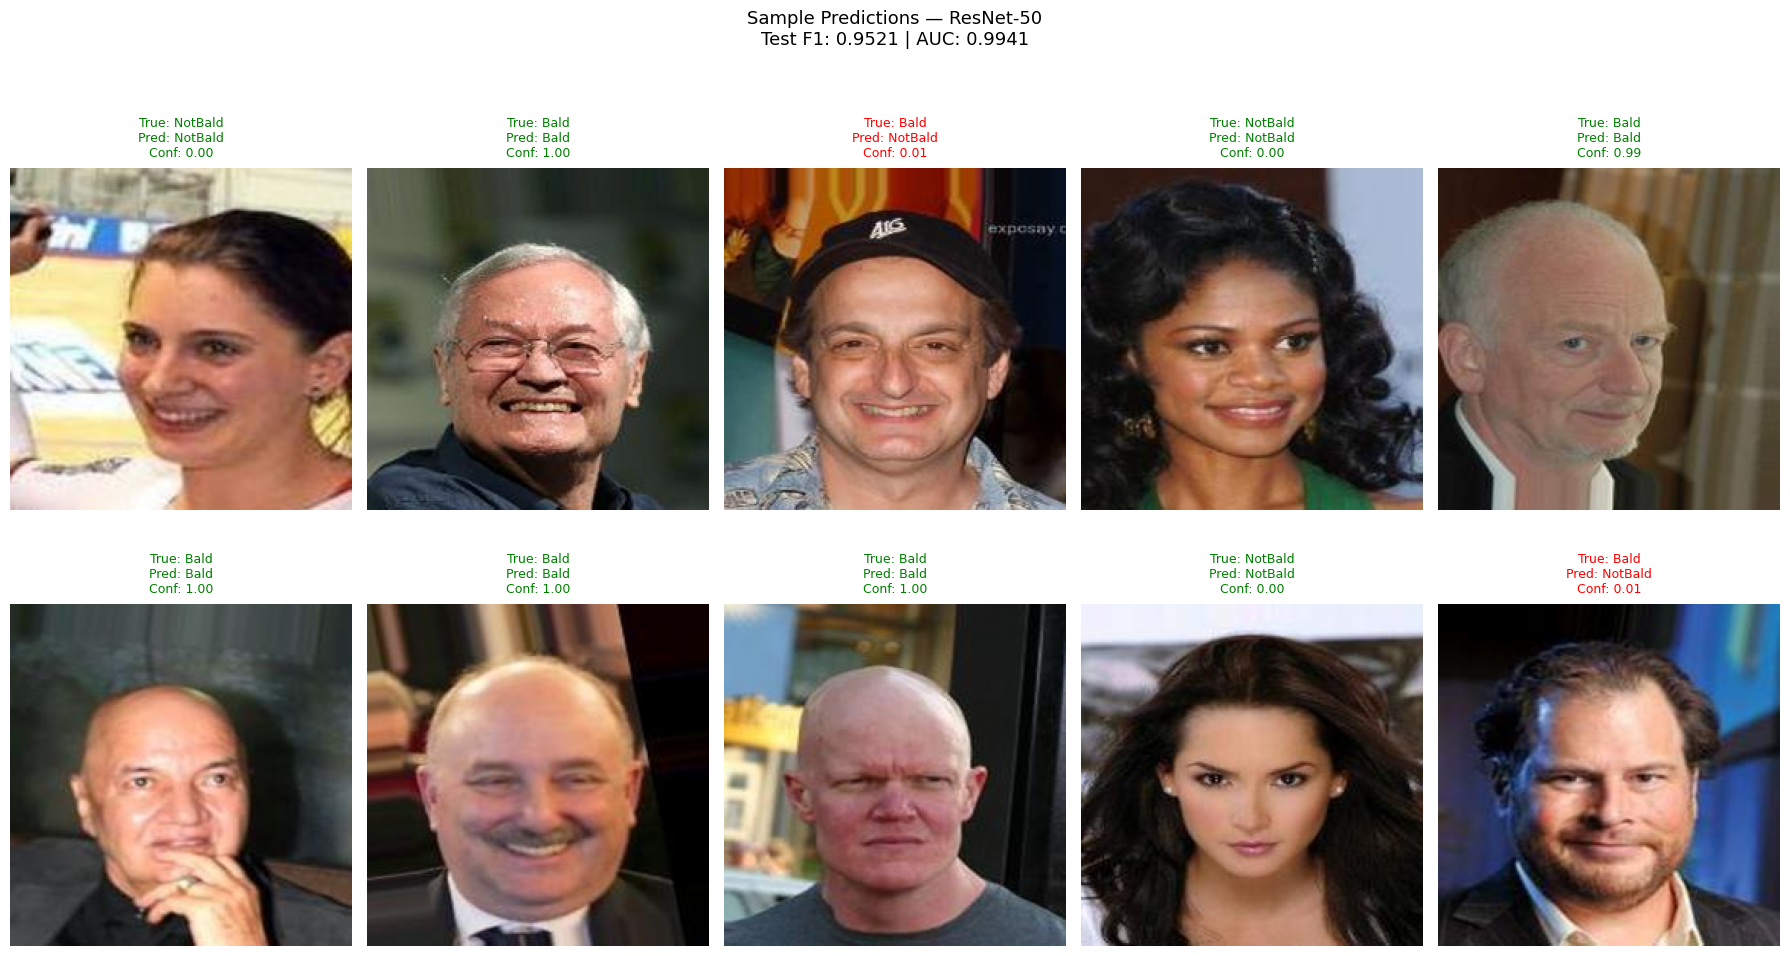

In [ ]:
# Visualisation — 10 sample images with predictions
# ImageNet normalisation constants — needed to reverse normalisation for display
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# Sample 10 images — mix of correct and incorrect predictions for interest
indices = random.sample(range(len(all_labels)), 10)

fig, axes = plt.subplots(2, 5, figsize=(18, 10)) 
axes = axes.flatten()

label_names = {0: "NotBald", 1: "Bald"}

for i, idx in enumerate(indices):
    arr         = np.frombuffer(images_bytes[idx], dtype=np.float32).reshape(224, 224, 3)
    arr_display = (arr * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

    true_label = label_names[all_labels[idx]]
    pred_label = label_names[all_preds[idx]]
    prob       = all_probs[idx]
    correct    = all_labels[idx] == all_preds[idx]

    axes[i].imshow(arr_display)
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {prob:.2f}", 
        fontsize=9,
        color="green" if correct else "red",
        pad=8,       
    )
    axes[i].axis("off")

plt.suptitle(
    f"Sample Predictions — {best_model_name}\n"
    f"Test F1: {test_metrics['f1']:.4f} | AUC: {test_metrics['auc']:.4f}",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

The figure above displays 10 sample predictions from the test set, each showing the 
true label, predicted label, and confidence score. The model predicts with high 
confidence in the vast majority of cases, with most scores at or near 1.00.

The two misclassified cases are particularly informative, a man wearing a **cap** 
(True: Bald, Pred: NotBald, Conf: 0.01) and a man with **visible hair but a receding 
hairline** (True: Bald, Pred: NotBald, Conf: 0.01). Both errors are understandable: 
the cap obscures the scalp entirely, and partial hair coverage can be ambiguous even 
for a human observer. These edge cases highlight the main limitation of the model,
it relies on visual scalp features that may not always be visible or unambiguous.